# SEIR-H Model for COVID-19 in Paraguay
**Reproduction of:** Shin et al. (2021) *A Mathematical Model for COVID-19 with Variable Transmissibility and Hospitalizations: A Case Study in Paraguay.* Applied Sciences, 11(20), 9726.

**Speed strategy:** MAP estimates via `scipy.optimize` instead of full MCMC. Expected runtime ≈ 2–5 min.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from cycler import cycler
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, differential_evolution
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ═══════════════════════════════════════════════════════════════
#  Visual identity — warm journal style
# ═══════════════════════════════════════════════════════════════
BG       = '#f6f1eb'
PANEL    = '#faf7f2'
GRID     = '#d4cdc4'
TEXT     = '#2d2a26'
SUBTLE   = '#7a7267'
RULE     = '#b8afa4'

BLUE     = '#2c5f8a'
RED      = '#b5453a'
GREEN    = '#457553'
AMBER    = '#c4863b'
PURPLE   = '#725e9c'
BAR_DATA = '#c0b8ad'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': RULE, 'axes.labelcolor': TEXT,
    'axes.titlepad': 12, 'axes.linewidth': 0.6,
    'text.color': TEXT, 'xtick.color': TEXT, 'ytick.color': TEXT,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.major.size': 4, 'ytick.major.size': 4,
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
    'grid.color': GRID, 'grid.alpha': 0.6, 'grid.linewidth': 0.3,
    'legend.facecolor': BG, 'legend.edgecolor': RULE,
    'legend.fontsize': 9, 'legend.framealpha': 0.9,
    'font.family': 'serif',
    'font.serif': ['Georgia','Times New Roman','DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 10.5, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.dpi': 130, 'savefig.dpi': 200, 'savefig.facecolor': BG,
    'axes.prop_cycle': cycler('color',[BLUE,RED,GREEN,AMBER,PURPLE]),
    'axes.spines.top': False, 'axes.spines.right': False,
})

def style_ax(ax, title=None, ylabel=None, xlabel=None, grid='y'):
    if title:
        ax.set_title(title, fontweight='normal', loc='left',
                     fontsize=11.5, color=TEXT, fontstyle='italic')
    if ylabel: ax.set_ylabel(ylabel)
    if xlabel: ax.set_xlabel(xlabel)
    if grid: ax.grid(True, axis=grid, linewidth=0.3, alpha=0.6)
    ax.spines['bottom'].set_color(RULE)
    ax.spines['left'].set_color(RULE)

def date_fmt(ax, interval=2):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)

def source_note(fig, text='Source: MSPyBS / DGVS Paraguay  |  Model: Shin et al., Appl. Sci. 2021'):
    fig.text(0.98, 0.006, text, ha='right', va='bottom',
             fontsize=7, color=SUBTLE, fontstyle='italic')

def panel_label(ax, label, x=-0.06, y=1.08):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=TEXT, va='top')

## 1. Load and Prepare Data

In [3]:
DATA = '/Users/fabian/Documents/epidemiology_downloads/downloads_set_1'

reg = pd.read_csv(f'{DATA}/REGISTRO_DIARIO_Datos_completos_data.csv', encoding='utf-8-sig')
reg.columns = reg.columns.str.strip()
reg['Fecha'] = pd.to_datetime(reg['Fecha'], dayfirst=True)
reg = reg.sort_values('Fecha').reset_index(drop=True)

conf = pd.read_csv(f'{DATA}/confirmado_diarios_revisado.csv')
conf['Fecha'] = pd.to_datetime(conf['Fecha'])

fall = pd.read_csv(f'{DATA}/Fallecidos_diarios_revisado.csv')
fall['Fecha'] = pd.to_datetime(fall['Fecha'])

df = reg[['Fecha','Confirmados en albergues','Confirmados Total',
          'Internados Generales','Internados UTI']].copy()
df = df.merge(conf[['Fecha','Confirmado_diario']], on='Fecha', how='left')
df = df.merge(fall[['Fecha','Fallecido_diario']], on='Fecha', how='left')
df = df.fillna(0)

t_start = pd.Timestamp('2020-03-07')
t_end   = pd.Timestamp('2021-05-22')
df = df[(df['Fecha']>=t_start)&(df['Fecha']<=t_end)].reset_index(drop=True)

dates = df['Fecha'].values
DR    = df['Confirmado_diario'].values.astype(float)
R_im  = df['Confirmados en albergues'].values.astype(float)
DH    = df['Internados Generales'].values.astype(float)
DU    = df['Internados UTI'].values.astype(float)
DF    = df['Fallecido_diario'].values.astype(float)
n_days = len(dates)
print(f'Data: {n_days} days, {dates[0]} to {dates[-1]}')

Data: 442 days, 2020-03-07T00:00:00.000000000 to 2021-05-22T00:00:00.000000000


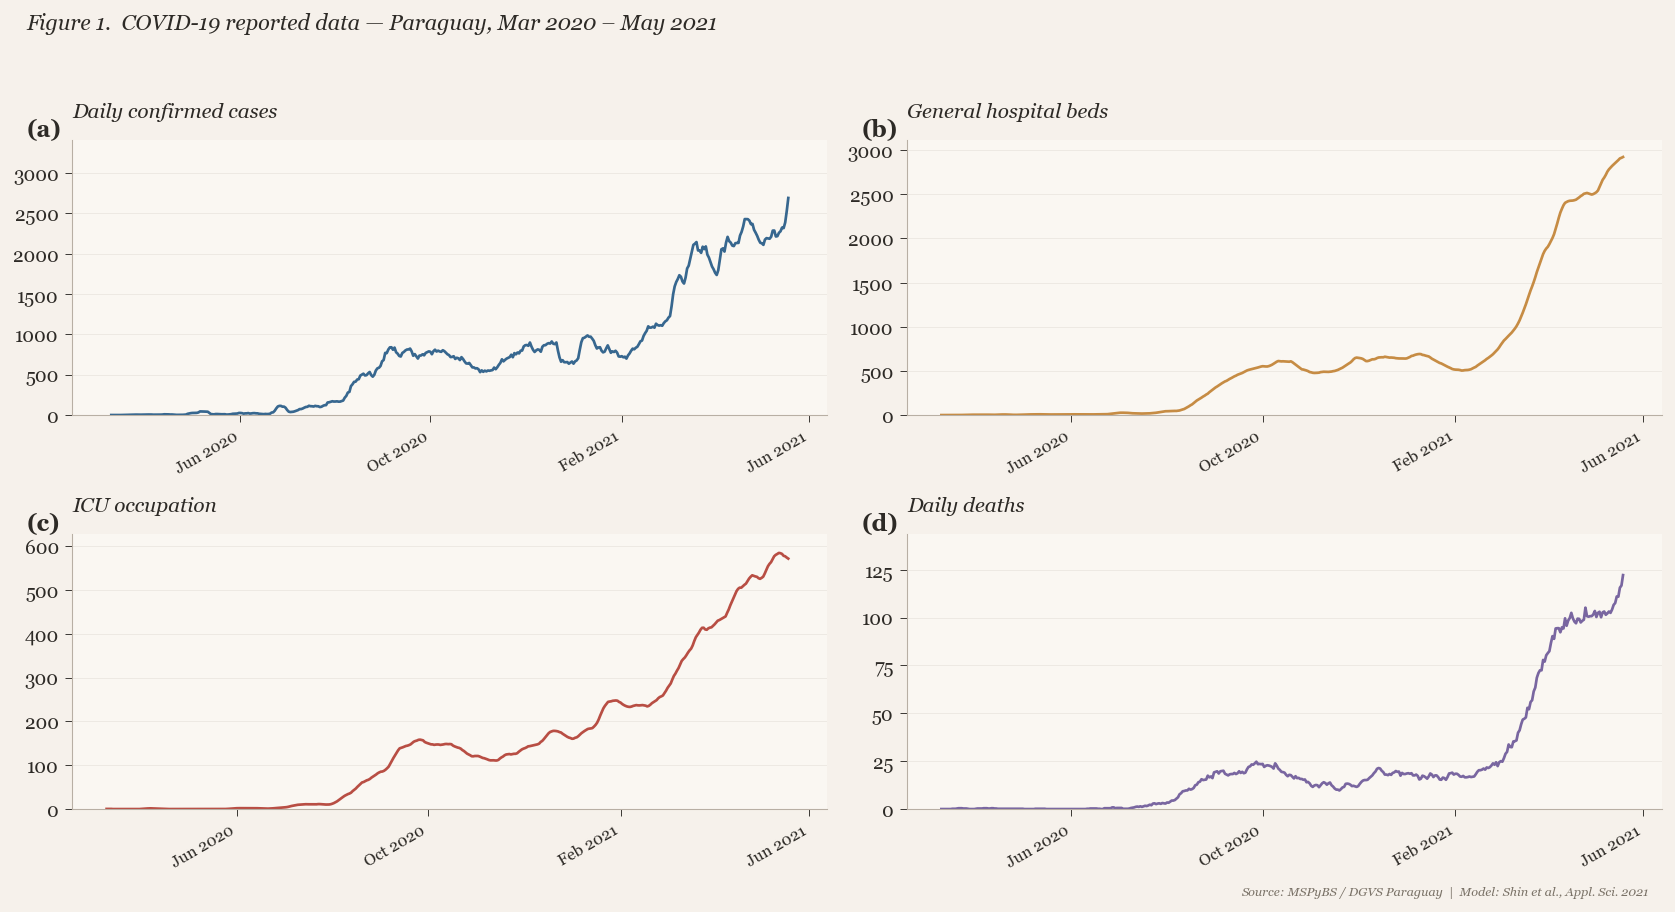

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.subplots_adjust(hspace=0.45, wspace=0.3)
for ax, (y, lbl, c, pan) in zip(axes.flat, [
    (DR, 'Daily confirmed cases',  BLUE,  '(a)'),
    (DH, 'General hospital beds',  AMBER, '(b)'),
    (DU, 'ICU occupation',         RED,   '(c)'),
    (DF, 'Daily deaths',           PURPLE,'(d)')]):
    ax.bar(dates, y, width=1, color=c, alpha=0.55, linewidth=0)
    if len(y) > 7:
        rm = pd.Series(y).rolling(7, center=True).mean()
        ax.plot(dates, rm, color=c, lw=1.5, alpha=0.95)
    style_ax(ax, title=lbl); panel_label(ax, pan); date_fmt(ax, 4)
fig.suptitle('Figure 1.  COVID-19 reported data — Paraguay, Mar 2020 – May 2021',
             fontsize=12, x=0.02, ha='left', fontstyle='italic')
source_note(fig)
plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

## 2. Fixed Parameters and ODE Solver

In [5]:
N_pop  = 7_252_671
alpha  = 1.0 / 3.0
gamma  = 1.0 / 7.0
W      = 14

delta_HU = 1.0/5.0;  delta_HF = 1.0/5.0;  delta_HO = 1.0/10.0
phi_UF   = 1.0/10.0; phi_UO   = 1.0/12.0

In [6]:
def euler_seir(S0, E0, I0, R0, beta, rim_arr, n_steps):
    S,E,I,R = np.empty(n_steps+1),np.empty(n_steps+1),np.empty(n_steps+1),np.empty(n_steps+1)
    S[0],E[0],I[0],R[0] = S0,E0,I0,R0
    for k in range(n_steps):
        rim = rim_arr[k] if k < len(rim_arr) else 0.0
        inf = beta*S[k]/N_pop*I[k]
        S[k+1]=S[k]-inf; E[k+1]=E[k]+inf-alpha*E[k]
        I[k+1]=I[k]+alpha*E[k]-gamma*I[k]; R[k+1]=R[k]+gamma*I[k]+rim
    return S,E,I,R

def neg_loglik_beta(params, S0, E0, I0, R0, DR_win, rim_win):
    beta = params[0]
    if beta<=0 or beta>=0.8: return 1e12
    _,_,_,R = euler_seir(S0,E0,I0,R0,beta,rim_win,W)
    dR_sim = np.diff(R)
    res = DR_win - dR_sim
    sig = max(np.std(res), 0.1)
    return 0.5*W*np.log(2*np.pi*sig**2) + np.sum(res**2)/(2*sig**2)

## 3. Estimate Initial Conditions ($e_0$, $i_0$, $\\beta_0$)

In [7]:
def neg_loglik_init(params):
    e0,i0,beta0 = params
    _,_,_,R = euler_seir(N_pop-e0-i0,e0,i0,0.0,beta0,R_im[:W],W)
    res = DR[:W] - np.diff(R)
    sig = max(np.std(res),0.1)
    return 0.5*W*np.log(2*np.pi*sig**2)+np.sum(res**2)/(2*sig**2)

res_init = differential_evolution(neg_loglik_init,
    [(0.1,100),(0.1,100),(0.01,0.8)], seed=42, maxiter=500, tol=1e-8)
e0_opt, i0_opt, beta0_opt = res_init.x
print(f'e0={e0_opt:.2f}  i0={i0_opt:.2f}  beta0={beta0_opt:.4f}  R0={beta0_opt/gamma:.2f}')

e0=0.10  i0=1.73  beta0=0.7520  R0=5.26


## 4. Estimate $\\beta(t)$ — Moving Window
Each window takes ~1 ms with scipy. Total: < 1 second for all windows.

In [8]:
%%time
n_windows = n_days - W
states = np.zeros((n_days+1, 4))
states[0] = [N_pop-e0_opt-i0_opt, e0_opt, i0_opt, 0.0]
beta_opt = np.zeros(n_windows)
beta_opt[0] = beta0_opt
Sa,Ea,Ia,Ra = euler_seir(*states[0], beta0_opt, R_im[0:1], 1)
states[1] = [Sa[1],Ea[1],Ia[1],Ra[1]]

for j in range(1, n_windows):
    S0,E0,I0,R0 = states[j]
    res = minimize(neg_loglik_beta, x0=[beta_opt[j-1]],
                   args=(S0,E0,I0,R0,DR[j:j+W],R_im[j:j+W]),
                   method='L-BFGS-B', bounds=[(1e-6,0.799)])
    beta_opt[j] = res.x[0]
    Sa,Ea,Ia,Ra = euler_seir(S0,E0,I0,R0,beta_opt[j],R_im[j:j+1],1)
    states[j+1] = [Sa[1],Ea[1],Ia[1],Ra[1]]

for j in range(n_windows+1, n_days+1):
    Sa,Ea,Ia,Ra = euler_seir(*states[j-1],beta_opt[-1],R_im[min(j,n_days-1):min(j,n_days-1)+1],1)
    states[j] = [Sa[1],Ea[1],Ia[1],Ra[1]]
print(f'Done: {n_windows} windows')

Done: 428 windows
CPU times: user 236 ms, sys: 48.5 ms, total: 285 ms
Wall time: 252 ms


## 5. Transmissibility and Reproduction Number

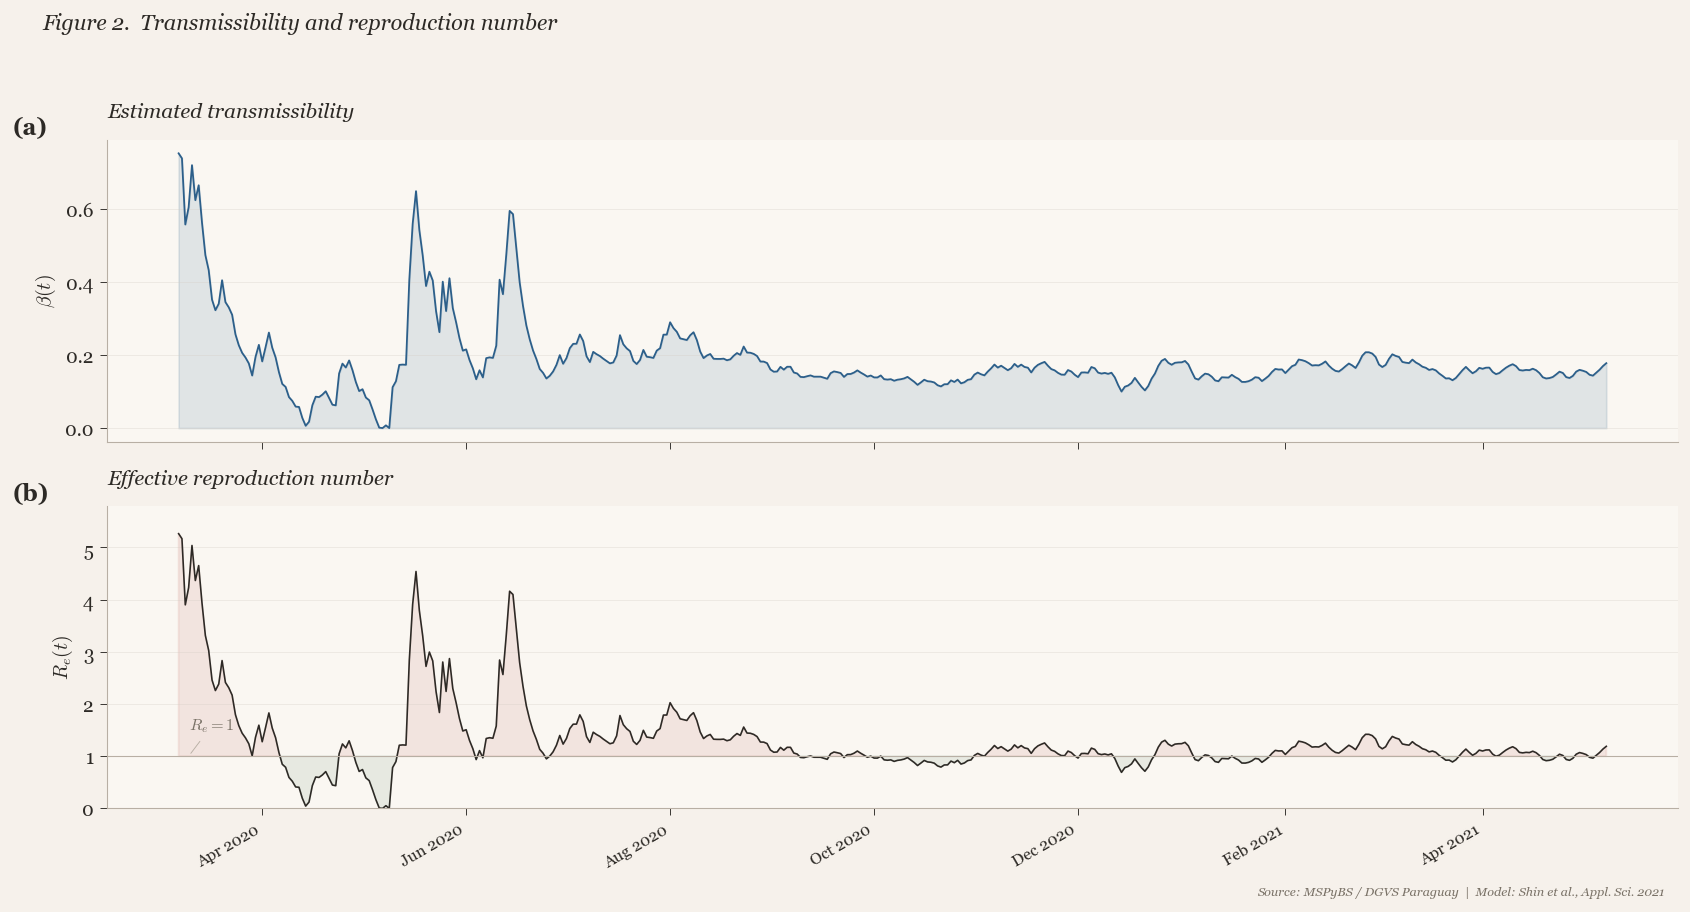

In [9]:
Re = beta_opt/gamma * states[:n_windows,0]/N_pop
beta_dates = dates[:n_windows]

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(13,7),sharex=True)
fig.subplots_adjust(hspace=0.15)

ax1.fill_between(beta_dates,0,beta_opt,color=BLUE,alpha=0.12)
ax1.plot(beta_dates,beta_opt,color=BLUE,lw=1)
style_ax(ax1,title='Estimated transmissibility',ylabel=r'$\beta(t)$')
panel_label(ax1,'(a)')

ax2.fill_between(beta_dates,1,Re,where=(Re>=1),color=RED,alpha=0.10,interpolate=True)
ax2.fill_between(beta_dates,Re,1,where=(Re<1),color=GREEN,alpha=0.10,interpolate=True)
ax2.plot(beta_dates,Re,color=TEXT,lw=0.9)
ax2.axhline(1.0,color=RULE,ls='-',lw=0.6)
ax2.annotate(r'$R_e=1$', xy=(beta_dates[3],1.0), xytext=(beta_dates[3],1.5),
             fontsize=9, color=SUBTLE,
             arrowprops=dict(arrowstyle='-',color=RULE,lw=0.5))
ax2.set_ylim(0,min(Re.max()*1.1,8))
style_ax(ax2,title='Effective reproduction number',ylabel=r'$R_e(t)$')
panel_label(ax2,'(b)'); date_fmt(ax2)

fig.suptitle('Figure 2.  Transmissibility and reproduction number',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

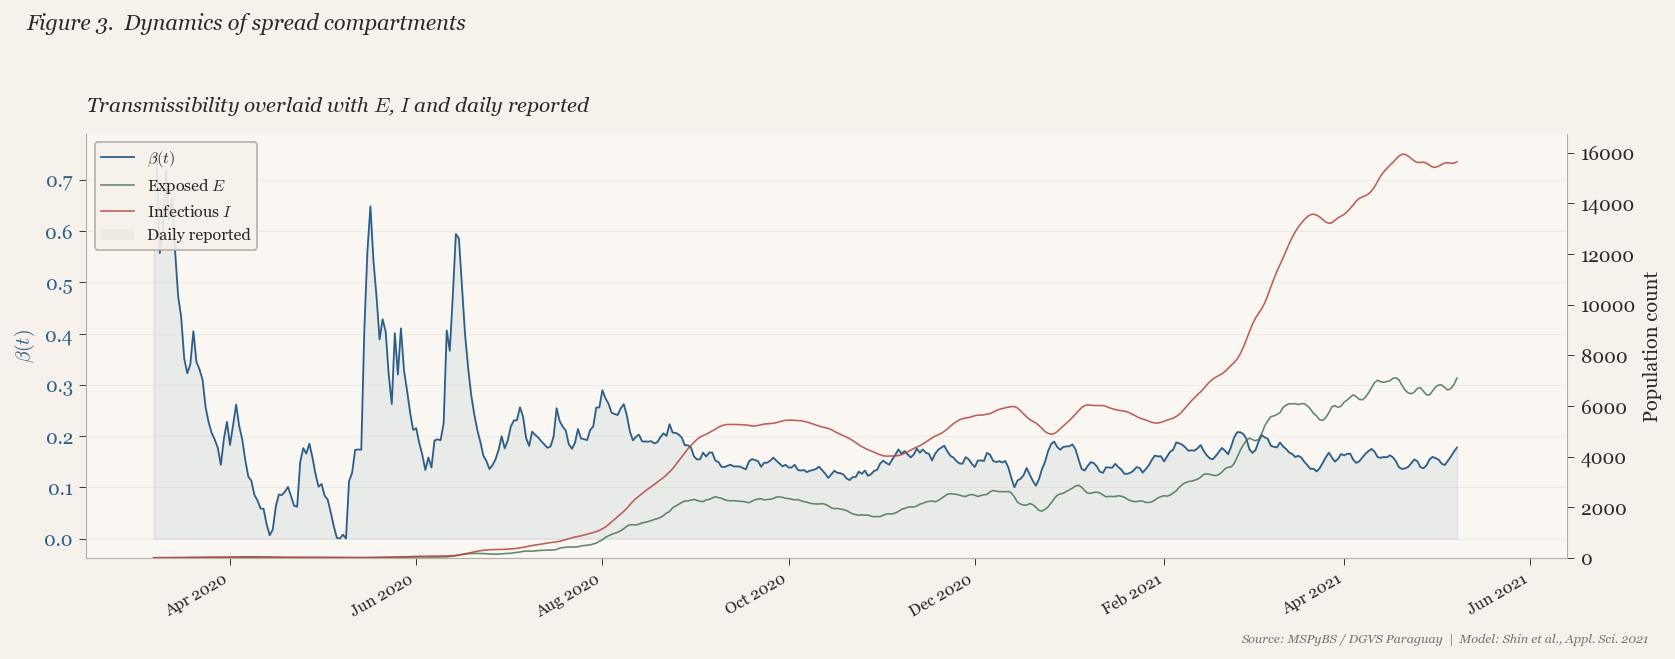

In [10]:
fig, ax1 = plt.subplots(figsize=(13,5))
ax1.fill_between(beta_dates,0,beta_opt,color=BLUE,alpha=0.08)
ax1.plot(beta_dates,beta_opt,color=BLUE,lw=1,label=r'$\beta(t)$')
ax1.set_ylabel(r'$\beta(t)$',color=BLUE)
ax1.tick_params(axis='y',labelcolor=BLUE)

ax2 = ax1.twinx()
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(RULE)
ax2.bar(dates,DR,width=1,alpha=0.12,color=BAR_DATA,label='Daily reported')
ax2.plot(dates[:n_windows],states[:n_windows,1],color=GREEN,lw=0.9,alpha=0.85,label='Exposed $E$')
ax2.plot(dates[:n_windows],states[:n_windows,2],color=RED,lw=0.9,alpha=0.85,label='Infectious $I$')
ax2.set_ylabel('Population count')
h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2,loc='upper left',framealpha=0.9)
style_ax(ax1,title=r'Transmissibility overlaid with $E$, $I$ and daily reported')
date_fmt(ax1)
fig.suptitle('Figure 3.  Dynamics of spread compartments',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

## 6. Daily Reported: Simulation vs Data

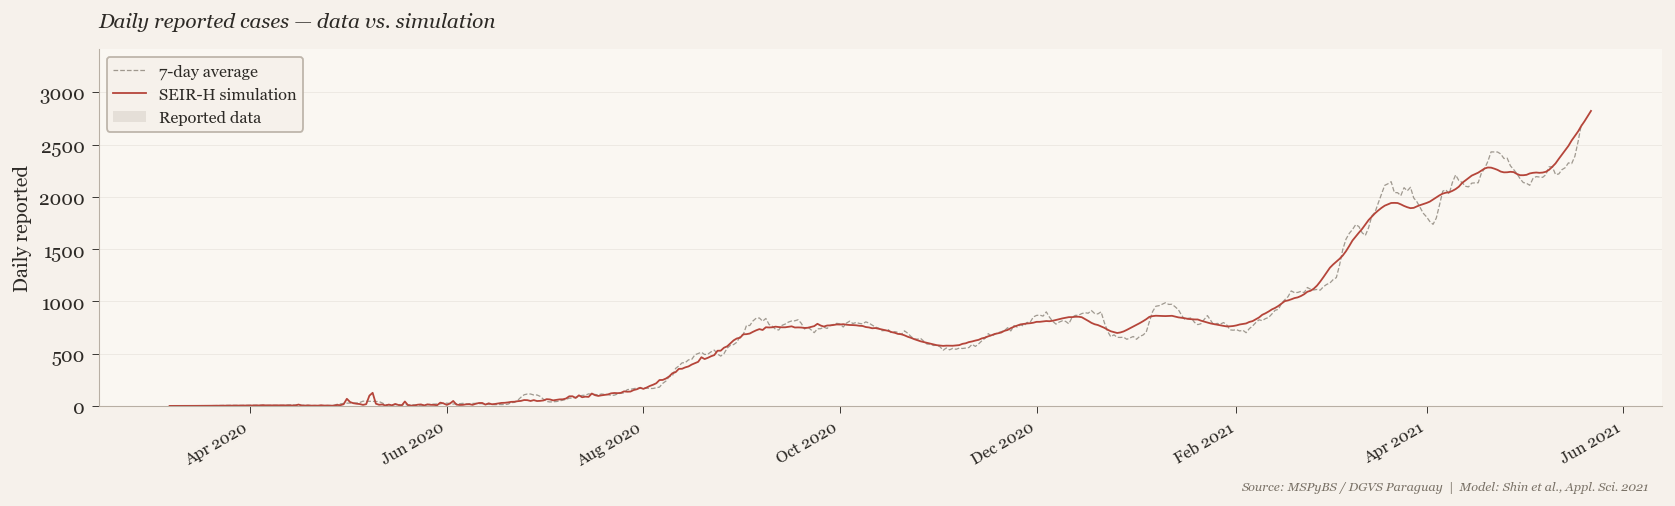

In [11]:
dR_sim = np.diff(states[:n_days+1,3])

fig, ax = plt.subplots(figsize=(13,4))
ax.bar(dates,DR,width=1,alpha=0.3,color=BAR_DATA,linewidth=0,label='Reported data')
rm = pd.Series(DR).rolling(7,center=True).mean()
ax.plot(dates,rm,color=SUBTLE,lw=0.7,ls='--',alpha=0.7,label='7-day average')
ax.plot(dates,dR_sim[:n_days],color=RED,lw=1,label='SEIR-H simulation')
style_ax(ax,title='Daily reported cases — data vs. simulation',ylabel='Daily reported')
ax.legend(); date_fmt(ax); source_note(fig)
plt.tight_layout(rect=[0,0.015,1,0.97]); plt.show()

## 7. Hospital Dynamics — Estimate $\\lambda_*$
Starts from Oct 5, 2020. Estimated every 7 days.

In [12]:
t_hosp = pd.Timestamp('2020-10-05')
j_h = int((t_hosp - t_start).days)

def neg_loglik_lambda(params, j, states, beta_opt):
    lam_IH,lam_IF,lam_HU,lam_HF,lam_UF = params
    if lam_HU+lam_HF>1 or lam_UF>1 or any(p<0 for p in params): return 1e12
    lam_HO=1-lam_HU-lam_HF; lam_UO=1-lam_UF
    S,E,I,R = states[j].copy()
    H=np.mean(DH[max(j-3,0):j+4]); U=np.mean(DU[max(j-3,0):j+4]); F_cum=0
    H_sim,U_sim,dF_sim = [],[],[]
    for k in range(W):
        jj=j+k; b=beta_opt[min(jj,len(beta_opt)-1)]; rim=R_im[min(jj,len(R_im)-1)]
        inf=b*S/N_pop*I; S-=inf; E_n=E+inf-alpha*E; I_n=I+alpha*E-gamma*I; R+=gamma*I+rim
        dH=lam_IH*gamma*I-lam_HU*delta_HU*H-lam_HF*delta_HF*H-lam_HO*delta_HO*H
        dU=lam_HU*delta_HU*H-lam_UF*phi_UF*U-lam_UO*phi_UO*U
        dF=lam_IF*gamma*I+lam_HF*delta_HF*H+lam_UF*phi_UF*U
        E,I=E_n,I_n; H=max(H+dH,0); U=max(U+dU,0); F_cum+=dF
        H_sim.append(H); U_sim.append(U); dF_sim.append(dF)
    H_sim=np.array(H_sim); U_sim=np.array(U_sim); dF_sim=np.array(dF_sim)
    DH_w=DH[j+1:j+1+W]; DU_w=DU[j+1:j+1+W]; DF_w=DF[j+1:j+1+W]
    if len(DH_w)<W: return 1e12
    sH=max(np.std(DH_w-H_sim),1); sU=max(np.std(DU_w-U_sim),1); sF=max(np.std(DF_w-dF_sim),0.1)
    nll = np.sum((DH_w-H_sim)**2)/(2*sH**2)+np.sum((DU_w-U_sim)**2)/(2*sU**2)+np.sum((DF_w-dF_sim)**2)/(2*sF**2)
    nll += (lam_UF-0.4)**2/(2*0.1**2)
    return nll
print(f'Hospital dynamics from index {j_h}')

Hospital dynamics from index 212


In [13]:
%%time
STEP=7; x0=[0.08,0.001,0.15,0.05,0.4]
bounds_lam=[(0.001,0.15),(0.0001,0.004),(0.001,0.30),(0.001,0.22),(0.2,1.0)]
lambda_results=[]; lambda_days=[]
for j in range(j_h, n_days-W, STEP):
    res=minimize(neg_loglik_lambda,x0=x0,args=(j,states,beta_opt),
                method='L-BFGS-B',bounds=bounds_lam)
    lam=dict(zip(['lam_IH','lam_IF','lam_HU','lam_HF','lam_UF'],res.x))
    lambda_results.append(lam); lambda_days.append(dates[j]); x0=list(res.x)
print(f'Done: {len(lambda_results)} windows')

Done: 31 windows
CPU times: user 282 ms, sys: 60.8 ms, total: 343 ms
Wall time: 297 ms


## 8. Estimated Hospital Proportions (Fig. 4)

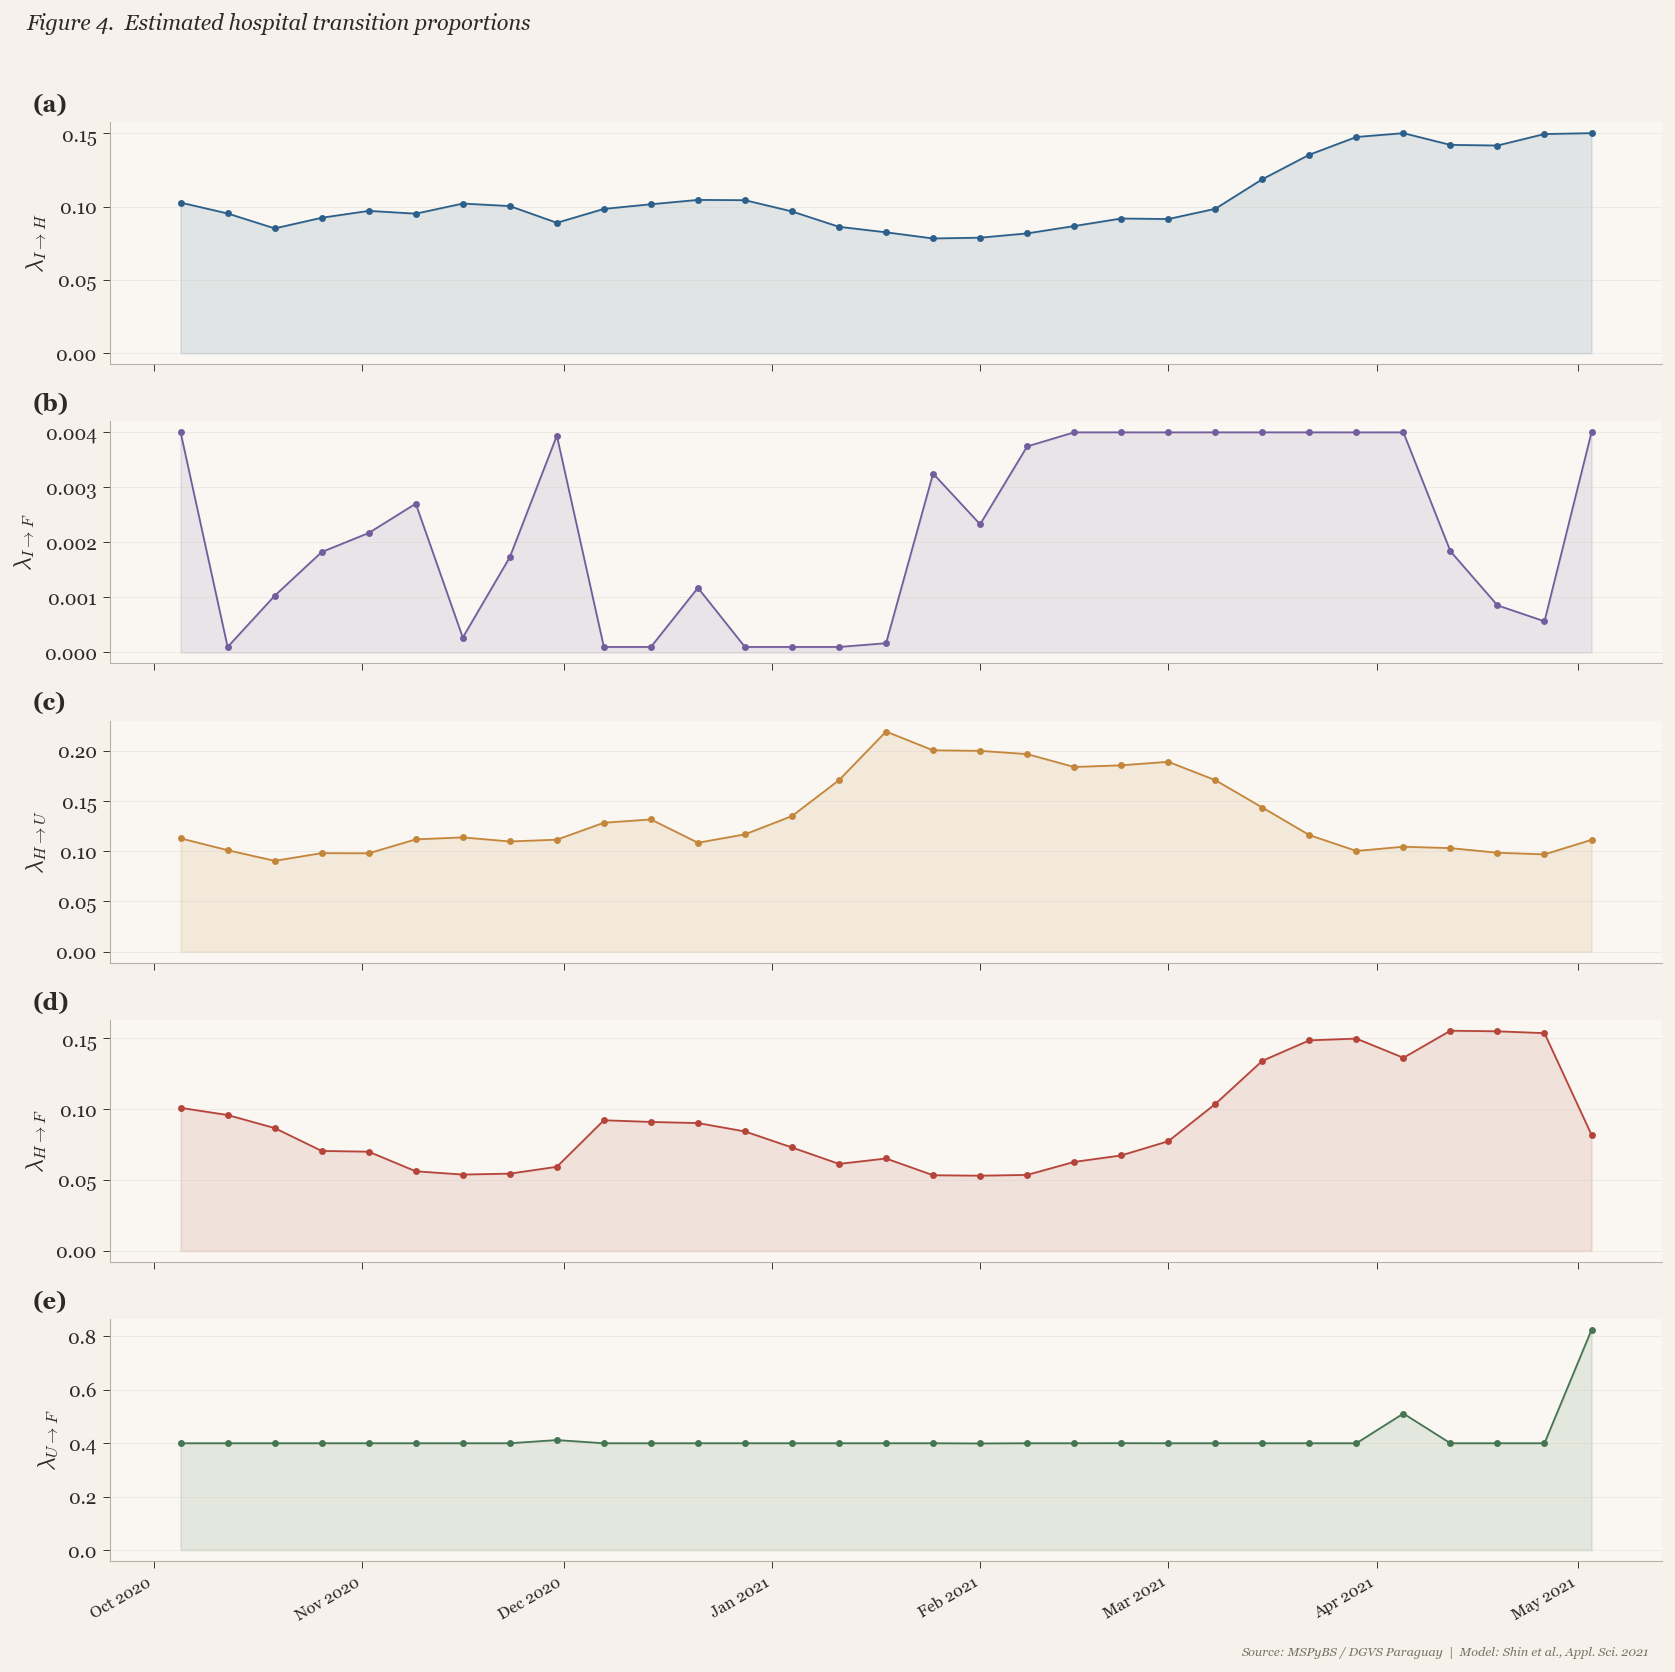

In [14]:
lam_names  = ['lam_IH','lam_IF','lam_HU','lam_HF','lam_UF']
lam_labels = [r'$\lambda_{I\rightarrow H}$',r'$\lambda_{I\rightarrow F}$',
              r'$\lambda_{H\rightarrow U}$',r'$\lambda_{H\rightarrow F}$',
              r'$\lambda_{U\rightarrow F}$']
lam_colors = [BLUE,PURPLE,AMBER,RED,GREEN]
panels = ['(a)','(b)','(c)','(d)','(e)']

fig, axes = plt.subplots(5,1,figsize=(13,13),sharex=True)
fig.subplots_adjust(hspace=0.08)
for ax,name,label,c,pan in zip(axes,lam_names,lam_labels,lam_colors,panels):
    vals=[r[name] for r in lambda_results]
    ax.fill_between(lambda_days,0,vals,color=c,alpha=0.12)
    ax.plot(lambda_days,vals,'-',lw=1,color=c)
    ax.scatter(lambda_days,vals,s=8,color=c,zorder=5)
    ax.set_ylabel(label,fontsize=13)
    style_ax(ax,grid='y'); panel_label(ax,pan,x=-0.05,y=1.12)
fig.suptitle('Figure 4.  Estimated hospital transition proportions',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
date_fmt(axes[-1],1); source_note(fig)
plt.tight_layout(rect=[0,0.015,1,0.97]); plt.show()

## 9. Full SEIR-H Simulation (Fig. 5)

In [15]:
n_hosp=n_days-j_h
lam_daily={n:np.zeros(n_hosp) for n in lam_names}
day_idx=[int((pd.Timestamp(d)-t_start).days)-j_h for d in lambda_days]
for name in lam_names:
    vals=[r[name] for r in lambda_results]
    for i in range(len(day_idx)):
        s=day_idx[i]; e=day_idx[i+1] if i+1<len(day_idx) else n_hosp
        lam_daily[name][max(s,0):min(e,n_hosp)]=vals[i]

S,E,I,R=states[j_h]; H=np.mean(DH[max(j_h-3,0):j_h+4])
U=np.mean(DU[max(j_h-3,0):j_h+4]); F_cum=0
H_s,U_s,dF_s=[H],[U],[]
for k in range(n_hosp-1):
    jj=j_h+k; b=beta_opt[min(jj,len(beta_opt)-1)]; rim=R_im[min(jj,len(R_im)-1)]
    l={n:lam_daily[n][k] for n in lam_names}
    lHO=max(1-l['lam_HU']-l['lam_HF'],0); lUO=max(1-l['lam_UF'],0)
    inf=b*S/N_pop*I; S-=inf; E_n=E+inf-alpha*E; I_n=I+alpha*E-gamma*I; R+=gamma*I+rim
    dH=l['lam_IH']*gamma*I-l['lam_HU']*delta_HU*H-l['lam_HF']*delta_HF*H-lHO*delta_HO*H
    dU=l['lam_HU']*delta_HU*H-l['lam_UF']*phi_UF*U-lUO*phi_UO*U
    dF=l['lam_IF']*gamma*I+l['lam_HF']*delta_HF*H+l['lam_UF']*phi_UF*U
    E,I=E_n,I_n; H=max(H+dH,0); U=max(U+dU,0); F_cum+=dF
    H_s.append(H); U_s.append(U); dF_s.append(dF)
H_s=np.array(H_s); U_s=np.array(U_s); dF_s=np.array(dF_s)
hosp_dates=dates[j_h:j_h+len(H_s)]

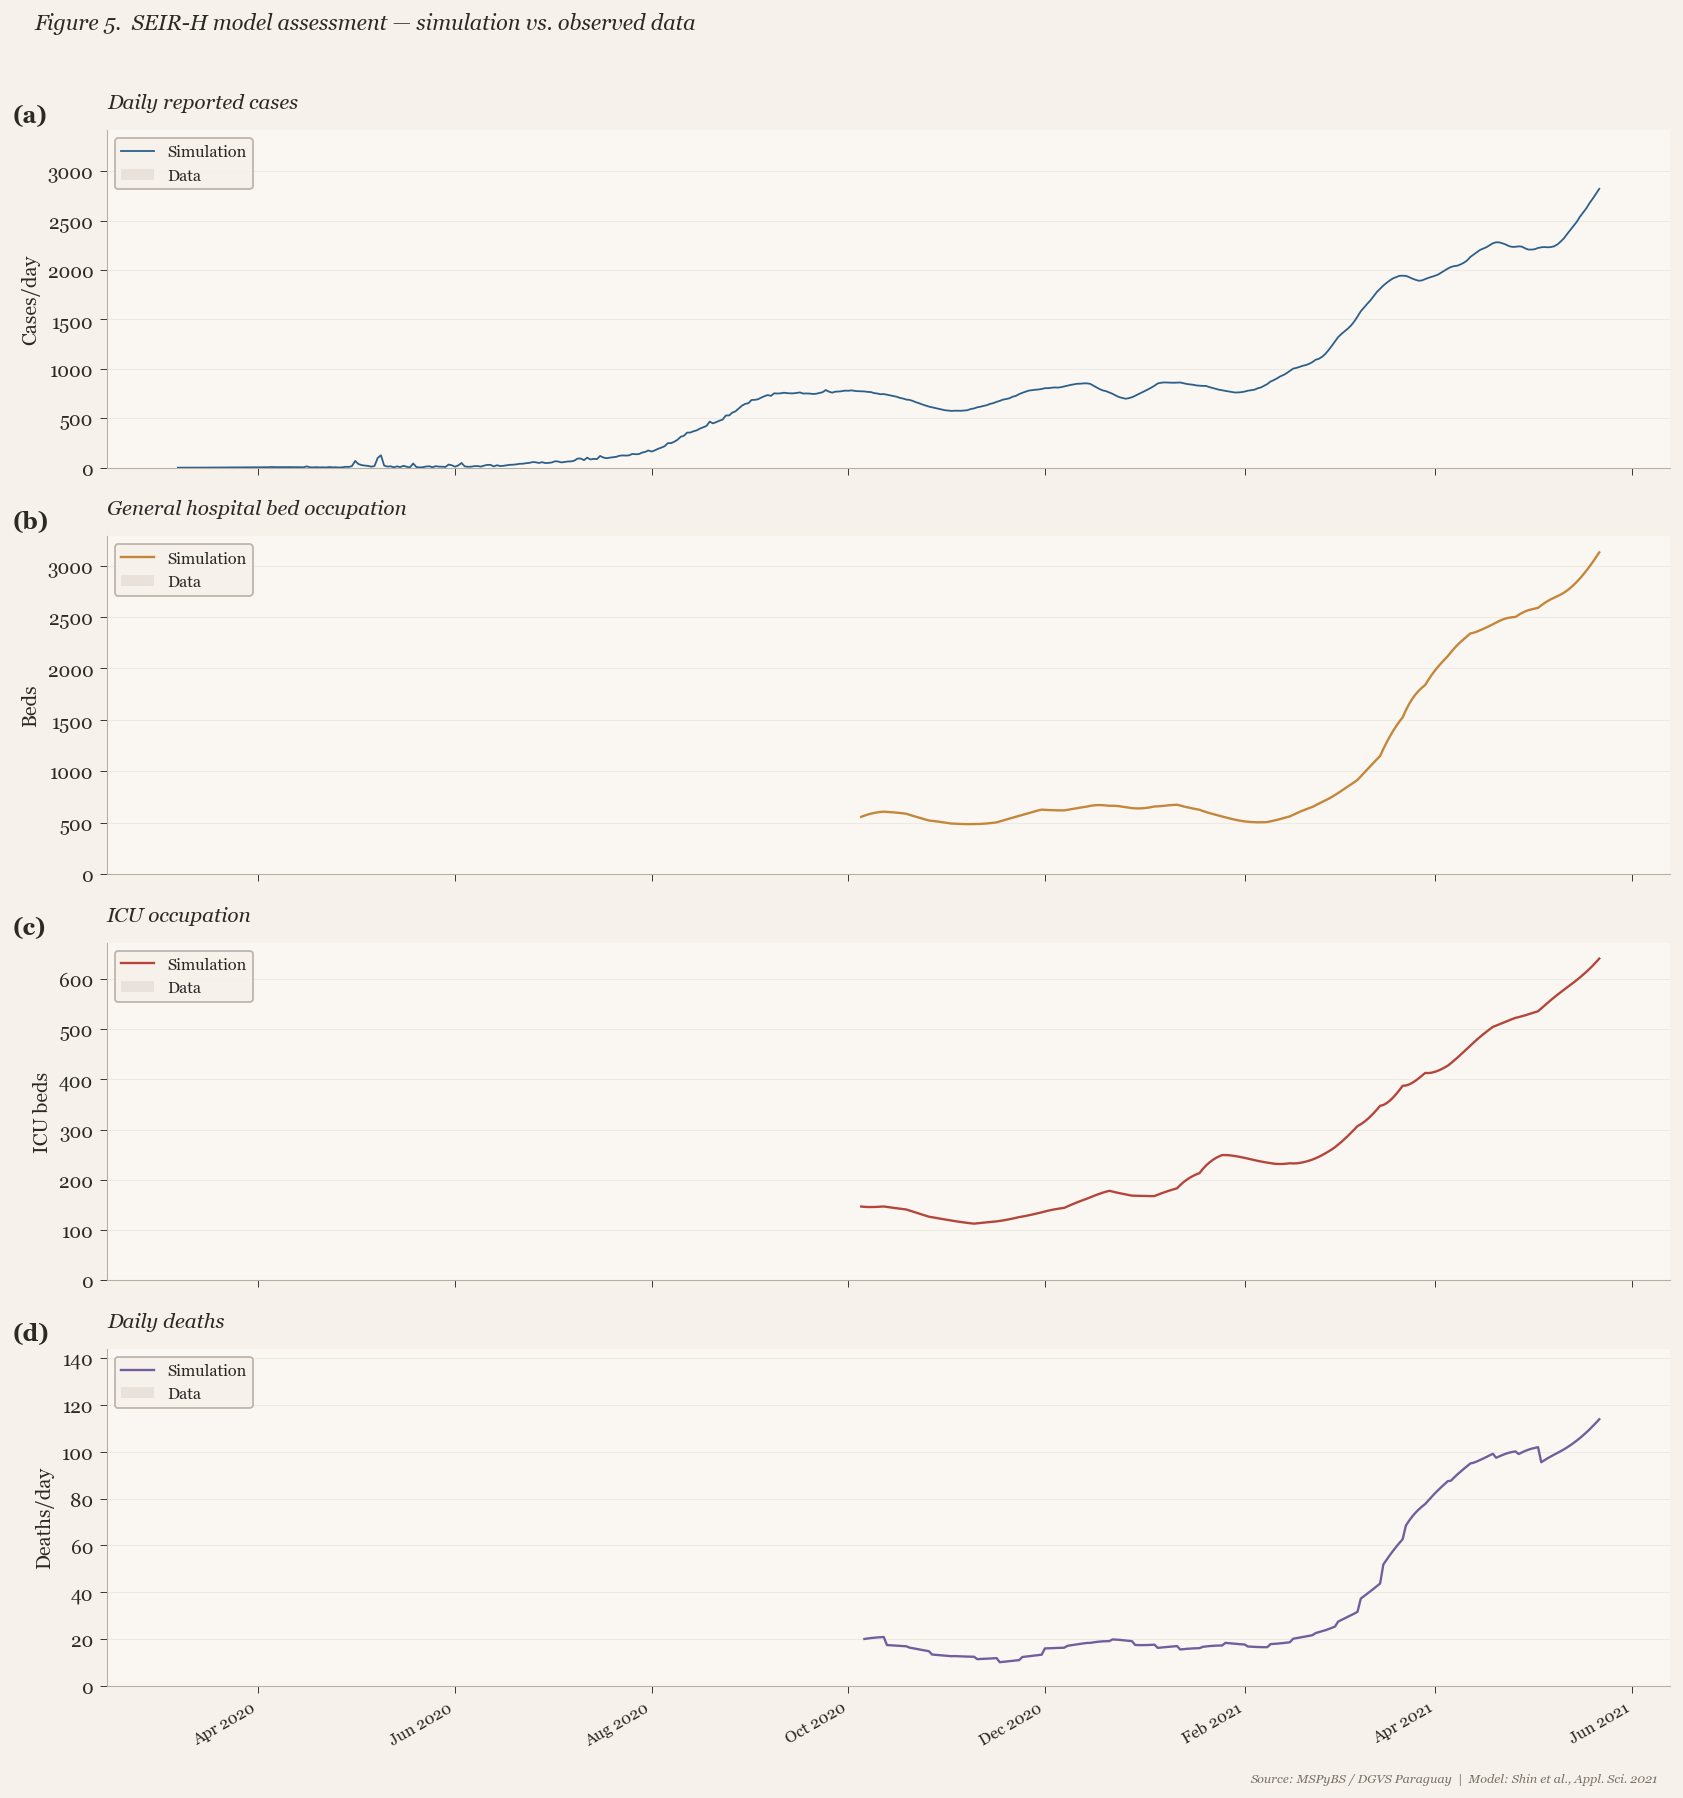

In [16]:
fig,axes=plt.subplots(4,1,figsize=(13,14),sharex=True)
fig.subplots_adjust(hspace=0.12)
n_h=len(hosp_dates); n_df=len(dF_s)

ax=axes[0]
ax.bar(dates,DR,width=1,alpha=0.25,color=BAR_DATA,linewidth=0,label='Data')
ax.plot(dates,dR_sim[:n_days],color=BLUE,lw=1,label='Simulation')
style_ax(ax,title='Daily reported cases',ylabel='Cases/day')
ax.legend(loc='upper left'); panel_label(ax,'(a)')

ax=axes[1]
ax.bar(hosp_dates,DH[j_h:j_h+n_h],width=1,alpha=0.25,color=BAR_DATA,linewidth=0,label='Data')
ax.plot(hosp_dates,H_s,color=AMBER,lw=1.3,label='Simulation')
style_ax(ax,title='General hospital bed occupation',ylabel='Beds')
ax.legend(loc='upper left'); panel_label(ax,'(b)')

ax=axes[2]
ax.bar(hosp_dates,DU[j_h:j_h+n_h],width=1,alpha=0.25,color=BAR_DATA,linewidth=0,label='Data')
ax.plot(hosp_dates,U_s,color=RED,lw=1.3,label='Simulation')
style_ax(ax,title='ICU occupation',ylabel='ICU beds')
ax.legend(loc='upper left'); panel_label(ax,'(c)')

ax=axes[3]
ax.bar(dates[j_h+1:j_h+1+n_df],DF[j_h+1:j_h+1+n_df],width=1,alpha=0.25,color=BAR_DATA,linewidth=0,label='Data')
ax.plot(dates[j_h+1:j_h+1+n_df],dF_s,color=PURPLE,lw=1.3,label='Simulation')
style_ax(ax,title='Daily deaths',ylabel='Deaths/day')
ax.legend(loc='upper left'); panel_label(ax,'(d)')

fig.suptitle('Figure 5.  SEIR-H model assessment — simulation vs. observed data',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
date_fmt(axes[-1]); source_note(fig)
plt.tight_layout(rect=[0,0.015,1,0.97]); plt.show()

## 10. Model Assessment (Table 4)

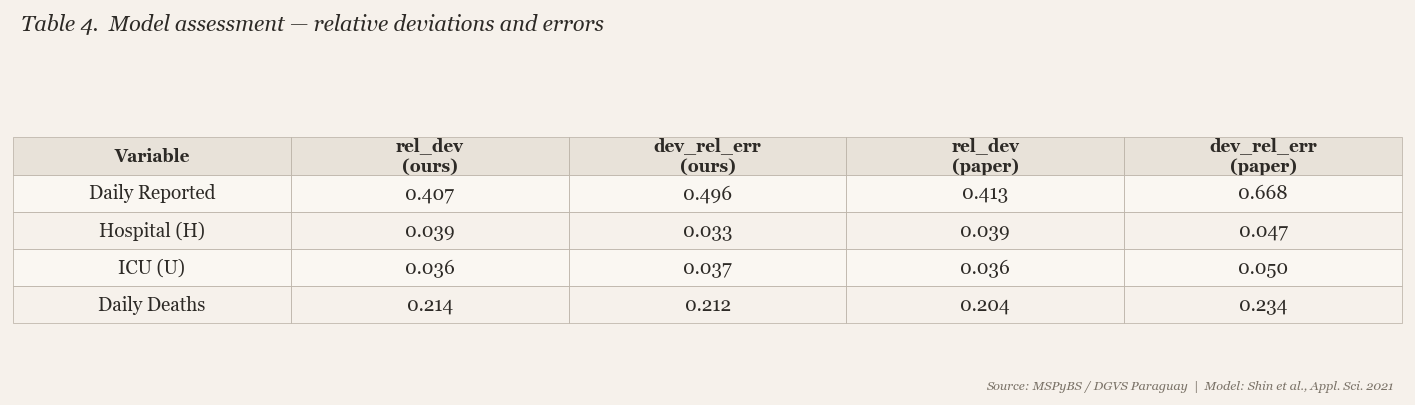

In [17]:
def rel_mean_dev(data,j0,j1):
    vals=[]
    for j in range(max(j0,3),min(j1,len(data)-3)):
        w=data[j-3:j+4]; m=np.mean(w)
        if m>0: vals.append(np.std(w,ddof=1)/m)
    return np.mean(vals) if vals else np.nan

def dev_rel_err(data,sim,n):
    e=[]
    for j in range(min(n,len(data),len(sim))):
        if abs(sim[j])>0.5: e.append(((data[j]-sim[j])/sim[j])**2)
    return np.sqrt(np.mean(e)) if e else np.nan

rows=[
    ('Daily Reported',rel_mean_dev(DR,0,n_days-W),
     dev_rel_err(DR,dR_sim,n_days-W),0.413,0.668),
    ('Hospital (H)',rel_mean_dev(DH,j_h,n_days-W),
     dev_rel_err(DH[j_h:j_h+len(H_s)],H_s,len(H_s)),0.039,0.047),
    ('ICU (U)',rel_mean_dev(DU,j_h,n_days-W),
     dev_rel_err(DU[j_h:j_h+len(U_s)],U_s,len(U_s)),0.036,0.050),
    ('Daily Deaths',rel_mean_dev(DF,j_h,n_days-W),
     dev_rel_err(DF[j_h+1:j_h+1+len(dF_s)],dF_s,len(dF_s)),0.204,0.234),
]

fig,ax=plt.subplots(figsize=(11,3))
ax.axis('off')
col_labels=['Variable','rel_dev\n(ours)','dev_rel_err\n(ours)','rel_dev\n(paper)','dev_rel_err\n(paper)']
cell_text=[[r[0],f'{r[1]:.3f}',f'{r[2]:.3f}',f'{r[3]:.3f}',f'{r[4]:.3f}'] for r in rows]
table=ax.table(cellText=cell_text,colLabels=col_labels,loc='center',cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10.5); table.scale(1.0,1.9)
for (row,col),cell in table.get_celld().items():
    cell.set_edgecolor(RULE); cell.set_linewidth(0.4)
    cell.set_text_props(color=TEXT,fontfamily='serif')
    if row==0:
        cell.set_facecolor('#e8e2d9'); cell.set_text_props(fontweight='bold',color=TEXT,fontsize=9.5)
    else:
        cell.set_facecolor(PANEL if row%2==1 else BG)
fig.suptitle('Table 4.  Model assessment — relative deviations and errors',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.02,1,0.93]); plt.show()

## 11. 30-Day Projection

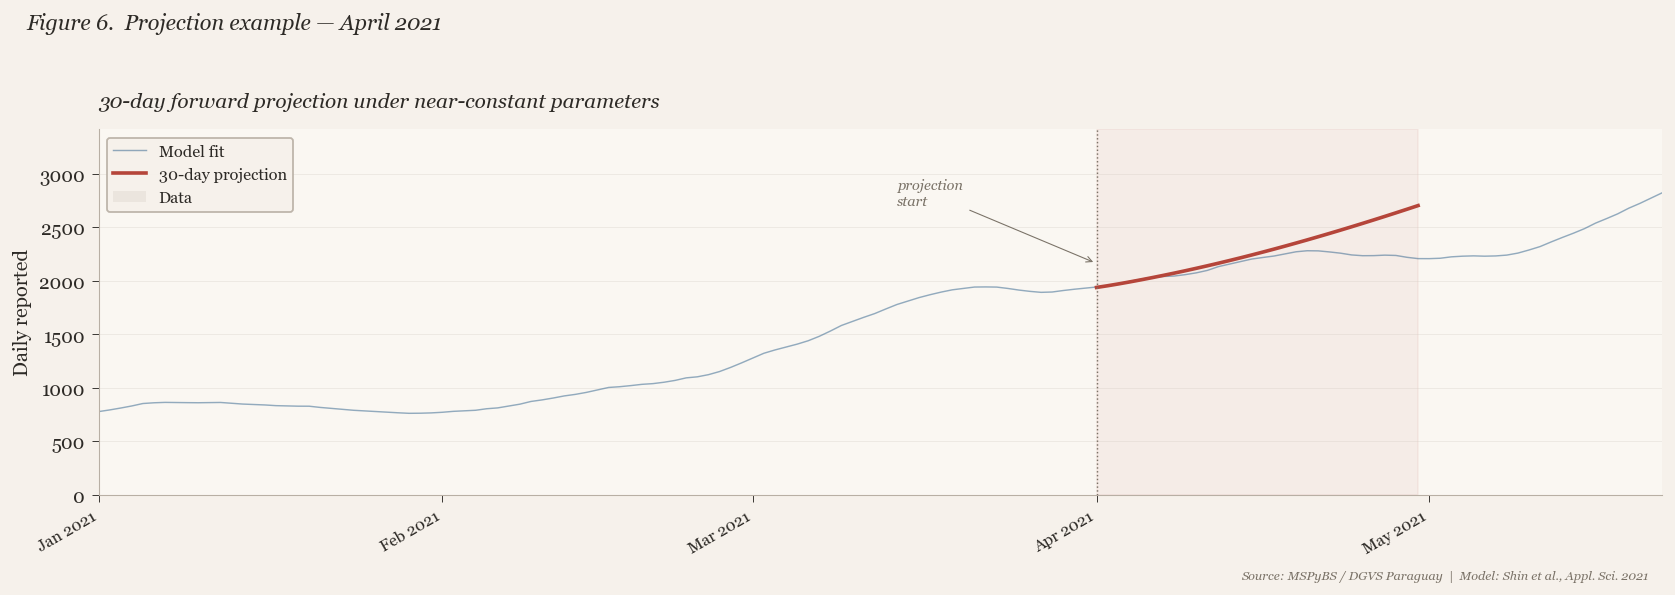

In [18]:
def sigmoid_beta_proj(beta_opt,j,W,Wp=30):
    b_j=beta_opt[min(j,len(beta_opt)-1)]
    recent=beta_opt[max(j-W,0):j]
    b_bar=(np.sum(recent)+W*b_j)/(2*W) if len(recent)>0 else b_j
    t=np.arange(Wp)
    return b_bar+(b_j-b_bar)/(1+np.exp((2/W)*(t-W/4)))

proj_from=pd.Timestamp('2021-04-01')
j_p=int((proj_from-t_start).days); Wp=30
bp=sigmoid_beta_proj(beta_opt,j_p-W,W,Wp)
S_p,E_p,I_p,R_p=states[j_p]
proj_dR=[]
for k in range(Wp):
    R_old=R_p; inf=bp[k]*S_p/N_pop*I_p
    S_p-=inf; E_n=E_p+inf-alpha*E_p; I_n=I_p+alpha*E_p-gamma*I_p; R_p+=gamma*I_p
    E_p,I_p=E_n,I_n; proj_dR.append(R_p-R_old)
proj_dates=pd.date_range(proj_from,periods=Wp)

fig,ax=plt.subplots(figsize=(13,4.5))
ax.bar(dates,DR,width=1,alpha=0.2,color=BAR_DATA,linewidth=0,label='Data')
ax.plot(dates,dR_sim[:n_days],color=BLUE,lw=0.8,alpha=0.5,label='Model fit')
ax.axvspan(proj_from,proj_dates[-1],alpha=0.06,color=RED,zorder=0)
ax.plot(proj_dates,proj_dR,color=RED,lw=2,label='30-day projection')
ax.axvline(proj_from,color=SUBTLE,ls=':',lw=0.8)
ax.annotate('projection\nstart',xy=(proj_from,max(proj_dR)*0.8),
            xytext=(proj_from-pd.Timedelta(days=18),max(proj_dR)*1.0),
            fontsize=8,color=SUBTLE,fontstyle='italic',
            arrowprops=dict(arrowstyle='->',color=SUBTLE,lw=0.6))
ax.set_xlim(pd.Timestamp('2021-01-01'),pd.Timestamp('2021-05-22'))
style_ax(ax,title='30-day forward projection under near-constant parameters',ylabel='Daily reported')
ax.legend(); date_fmt(ax,1)
fig.suptitle('Figure 6.  Projection example — April 2021',
             fontsize=12,x=0.02,ha='left',fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

---
# Part II — Extension: SVEIR-H with Vaccination

We extend the model with **separate vaccinated compartments** $V$, $E_v$, $I_v$, following a more mechanistically correct formulation:

- **$V$**: vaccinated but not yet exposed — protected with efficacy $\varepsilon$
- **$E_v$**: vaccinated-exposed (breakthrough latent period)
- **$I_v$**: vaccinated-infectious — contributes $\kappa \cdot I_v$ to force of infection ($\kappa < 1$, reduced transmissibility)
- **$\omega$**: waning rate ($V \rightarrow S$)
- **$\gamma_v$**: faster viral clearance for vaccinated infectious

$$\frac{dS}{dt} = -\beta \frac{S}{N}(I + \kappa I_v) - v(t) + \omega V$$

$$\frac{dV}{dt} = v(t) - (1-\varepsilon)\beta \frac{V}{N}(I + \kappa I_v) - \omega V$$

$$\frac{dE_v}{dt} = (1-\varepsilon)\beta \frac{V}{N}(I + \kappa I_v) - \alpha E_v$$

$$\frac{dI_v}{dt} = \alpha E_v - \gamma_v I_v$$

## 12. Load Vaccination Data and Extend Study Period

In [19]:
vax = pd.read_csv(f'{DATA}/Inmunizado_diarios.csv')
vax['Fecha'] = pd.to_datetime(vax['Fecha'])
vax = vax.sort_values('Fecha').reset_index(drop=True)

t_end_ext = pd.Timestamp('2021-10-31')

reg_ext = pd.read_csv(f'{DATA}/REGISTRO_DIARIO_Datos_completos_data.csv', encoding='utf-8-sig')
reg_ext.columns = reg_ext.columns.str.strip()
reg_ext['Fecha'] = pd.to_datetime(reg_ext['Fecha'], dayfirst=True)
reg_ext = reg_ext.sort_values('Fecha').reset_index(drop=True)

conf_ext = pd.read_csv(f'{DATA}/confirmado_diarios_revisado.csv')
conf_ext['Fecha'] = pd.to_datetime(conf_ext['Fecha'])
fall_ext = pd.read_csv(f'{DATA}/Fallecidos_diarios_revisado.csv')
fall_ext['Fecha'] = pd.to_datetime(fall_ext['Fecha'])

df_ext = reg_ext[['Fecha','Confirmados en albergues','Confirmados Total',
                  'Internados Generales','Internados UTI']].copy()
df_ext = df_ext.merge(conf_ext[['Fecha','Confirmado_diario']], on='Fecha', how='left')
df_ext = df_ext.merge(fall_ext[['Fecha','Fallecido_diario']], on='Fecha', how='left')
df_ext = df_ext.merge(vax[['Fecha','Inmunizado_diario']], on='Fecha', how='left')
df_ext = df_ext.fillna(0)
df_ext = df_ext[(df_ext['Fecha']>=t_start)&(df_ext['Fecha']<=t_end_ext)].reset_index(drop=True)

dates_ext  = df_ext['Fecha'].values
DR_ext     = df_ext['Confirmado_diario'].values.astype(float)
R_im_ext   = df_ext['Confirmados en albergues'].values.astype(float)
DH_ext     = df_ext['Internados Generales'].values.astype(float)
DU_ext     = df_ext['Internados UTI'].values.astype(float)
DF_ext     = df_ext['Fallecido_diario'].values.astype(float)
V_daily    = df_ext['Inmunizado_diario'].values.astype(float)
n_days_ext = len(dates_ext)

print(f'Extended period: {n_days_ext} days, {dates_ext[0]} to {dates_ext[-1]}')
print(f'Total vaccinations: {V_daily.sum():,.0f}')
vax_start = pd.Timestamp('2021-03-02')
print(f'Vaccination starts: {vax_start.date()}')

Extended period: 604 days, 2020-03-07T00:00:00.000000000 to 2021-10-31T00:00:00.000000000
Total vaccinations: 2,361,819
Vaccination starts: 2021-03-02


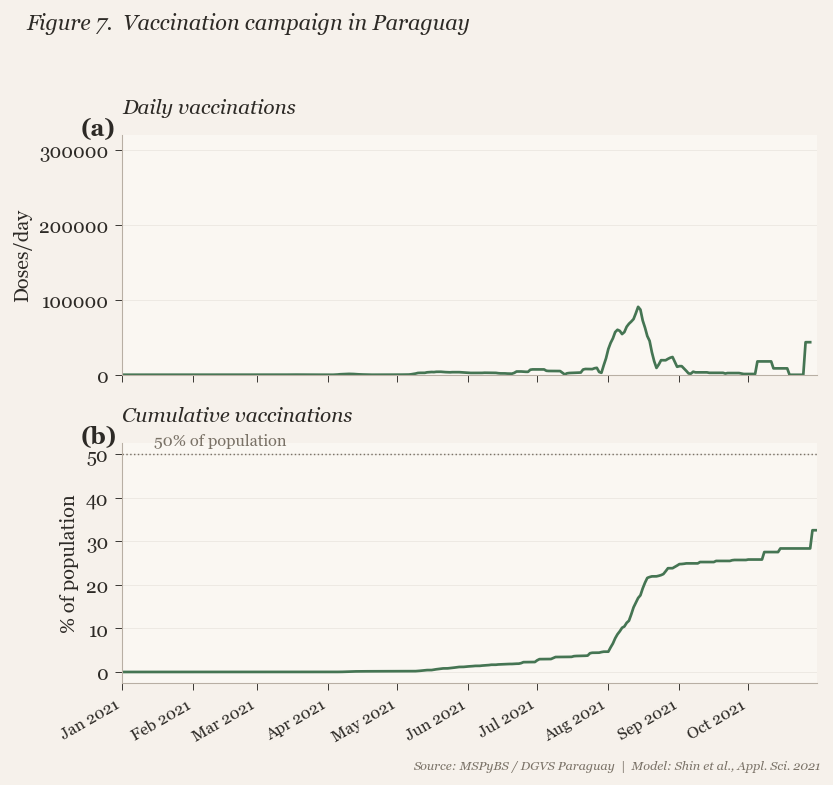

In [32]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6.5,6),sharex=True)
fig.subplots_adjust(hspace=0.15)
ax1.bar(dates_ext, V_daily, width=1, color=GREEN, alpha=0.6, linewidth=0)
rm_v = pd.Series(V_daily).rolling(7,center=True).mean()
ax1.plot(dates_ext, rm_v, color=GREEN, lw=1.5)
style_ax(ax1, title='Daily vaccinations', ylabel='Doses/day')
panel_label(ax1,'(a)')
ax2.plot(dates_ext, np.cumsum(V_daily)/N_pop*100, color=GREEN, lw=1.5)
ax2.axhline(50, color=SUBTLE, ls=':', lw=0.8)
ax2.text(pd.Timestamp('2021-01-15'), 52, '50% of population', color=SUBTLE, fontsize=9)
style_ax(ax2, title='Cumulative vaccinations', ylabel='% of population')
panel_label(ax2,'(b)'); date_fmt(ax2, interval=1)
ax2.set_xlim(pd.Timestamp('2021-01-01'), dates_ext[-1])
fig.suptitle('Figure 7.  Vaccination campaign in Paraguay',
             fontsize=12, x=0.04, ha='left', fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

## 13. SVEIR-H Parameters and Solver

In [21]:
# ── New parameters ──
eps     = 0.70    # vaccine efficacy vs infection
eta     = 0.87    # vaccine efficacy vs severe disease
kappa   = 0.50    # reduced transmissibility of vaccinated-infectious
gamma_v = 1.0/5.0 # faster clearance for vaccinated (5 days vs 7)
omega   = 1.0/180 # waning rate (protection ~6 months)

def euler_sveir(S0, V0, E0, I0, Ev0, Iv0, R0,
                beta, rim_arr, v_arr, n_steps):
    """Forward Euler for SVEIR with Ev, Iv compartments.
    State order: S, V, E, I, Ev, Iv, R  (7 compartments)"""
    n = n_steps + 1
    S  = np.empty(n); V  = np.empty(n); E  = np.empty(n)
    I  = np.empty(n); Ev = np.empty(n); Iv = np.empty(n)
    R  = np.empty(n)
    S[0],V[0],E[0],I[0],Ev[0],Iv[0],R[0] = S0,V0,E0,I0,Ev0,Iv0,R0

    for k in range(n_steps):
        rim = rim_arr[k] if k < len(rim_arr) else 0.0
        vk  = v_arr[k]   if k < len(v_arr) else 0.0
        vk  = min(vk, max(S[k], 0))  # can't vaccinate more than S

        # Force of infection
        foi = beta * (I[k] + kappa * Iv[k]) / N_pop

        # Unvaccinated track
        inf_s = foi * S[k]
        # Vaccinated track
        inf_v = (1 - eps) * foi * V[k]

        S[k+1]  = S[k]  - inf_s - vk + omega * V[k]
        V[k+1]  = V[k]  + vk - inf_v - omega * V[k]
        E[k+1]  = E[k]  + inf_s - alpha * E[k]
        I[k+1]  = I[k]  + alpha * E[k] - gamma * I[k]
        Ev[k+1] = Ev[k] + inf_v - alpha * Ev[k]
        Iv[k+1] = Iv[k] + alpha * Ev[k] - gamma_v * Iv[k]
        R[k+1]  = R[k]  + gamma * I[k] + gamma_v * Iv[k] + rim

    return S, V, E, I, Ev, Iv, R

print('SVEIR solver defined — 7 compartments')

SVEIR solver defined — 7 compartments


## 14. Re-estimate $\\beta(t)$ for the Extended Period

In [22]:
def nll_beta_sveir(params, s0, rim_win, v_win, DR_win):
    beta = params[0]
    if beta <= 0 or beta >= 0.8: return 1e12
    _,_,_,_,_,_,Rv = euler_sveir(*s0, beta, rim_win, v_win, W)
    dR_sim = np.diff(Rv)
    res = DR_win - dR_sim
    sig = max(np.std(res), 0.1)
    return 0.5*W*np.log(2*np.pi*sig**2) + np.sum(res**2)/(2*sig**2)

In [23]:
%%time
n_win_ext = n_days_ext - W

# State: S, V, E, I, Ev, Iv, R
states_ext = np.zeros((n_days_ext + 1, 7))
states_ext[0] = [N_pop - e0_opt - i0_opt, 0.0, e0_opt, i0_opt, 0.0, 0.0, 0.0]
beta_ext = np.zeros(n_win_ext)
beta_ext[0] = beta0_opt

# First step
out = euler_sveir(*states_ext[0], beta0_opt, R_im_ext[0:1], V_daily[0:1], 1)
states_ext[1] = [o[1] for o in out]

for j in range(1, n_win_ext):
    s = states_ext[j]
    res = minimize(nll_beta_sveir, x0=[beta_ext[j-1]],
                   args=(s, R_im_ext[j:j+W], V_daily[j:j+W], DR_ext[j:j+W]),
                   method='L-BFGS-B', bounds=[(1e-6, 0.799)])
    beta_ext[j] = res.x[0]
    out = euler_sveir(*s, beta_ext[j], R_im_ext[j:j+1], V_daily[j:j+1], 1)
    states_ext[j+1] = [o[1] for o in out]

# Fill tail
for j in range(n_win_ext+1, n_days_ext+1):
    s = states_ext[j-1]
    jj = min(j, n_days_ext-1)
    out = euler_sveir(*s, beta_ext[-1], R_im_ext[jj:jj+1], V_daily[jj:jj+1], 1)
    states_ext[j] = [o[1] for o in out]

dR_sim_ext = np.diff(states_ext[:, 6])  # daily reported
print(f'Done: {n_win_ext} windows')

Done: 590 windows
CPU times: user 451 ms, sys: 83.1 ms, total: 534 ms
Wall time: 474 ms


## 15. Decomposed Reproduction Number

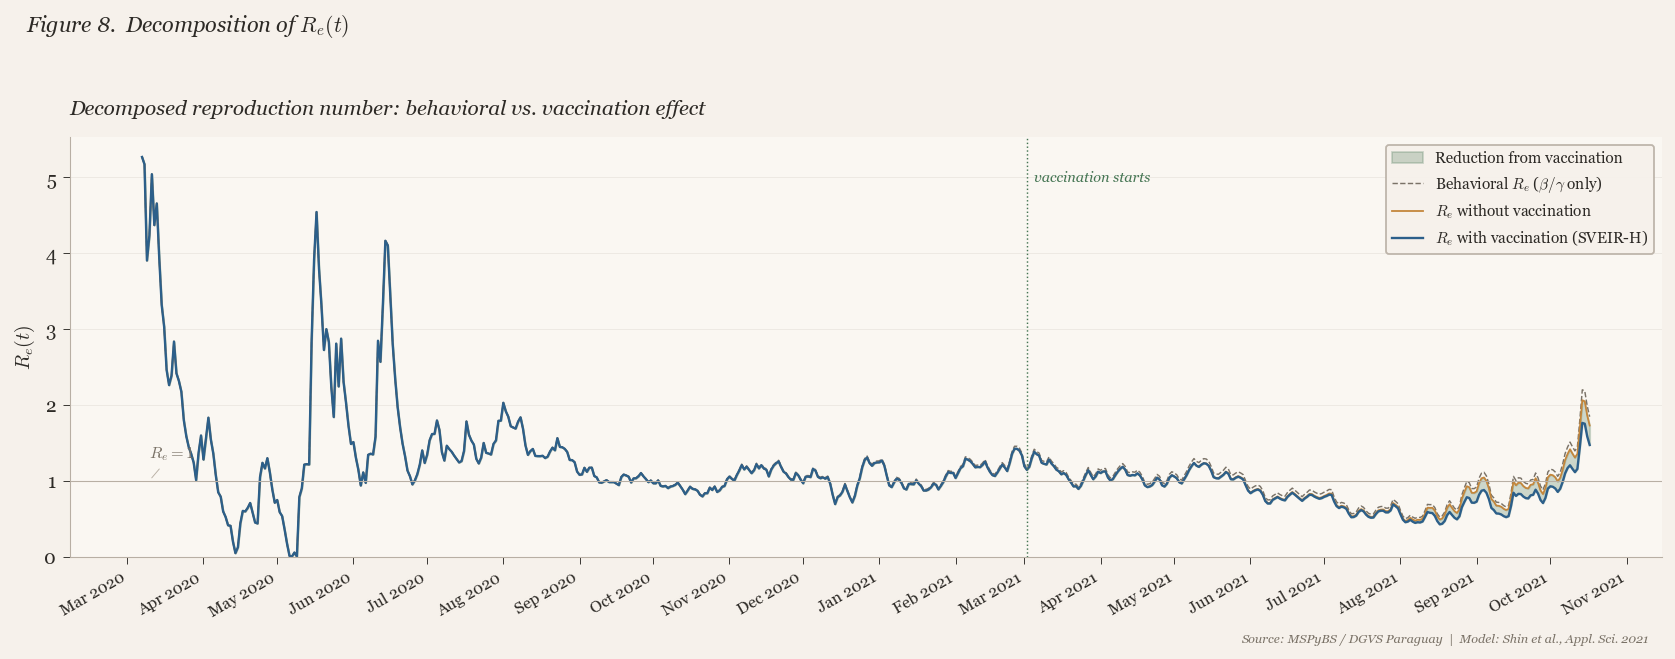

In [30]:
beta_dates_ext = dates_ext[:n_win_ext]
St = states_ext[:n_win_ext, 0]  # S
Vt = states_ext[:n_win_ext, 1]  # V
Ivt = states_ext[:n_win_ext, 5] # Iv
It  = states_ext[:n_win_ext, 3] # I

# Full Re: accounts for reduced susceptibility of V and reduced
# transmissibility of Iv
Re_full = beta_ext/gamma * (St + (1-eps)*Vt) / N_pop

# Behavioral Re: beta/gamma only (what if everyone susceptible)
Re_behav = beta_ext / gamma

# Re without vaccine (S+V all susceptible, no kappa reduction)
Re_no_vax = beta_ext/gamma * (St + Vt) / N_pop

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(beta_dates_ext, Re_full, Re_no_vax,
                color=GREEN, alpha=0.25, label='Reduction from vaccination')
ax.plot(beta_dates_ext, Re_behav, color=SUBTLE, lw=0.8, ls='--',
        label=r'Behavioral $R_e$ ($\beta/\gamma$ only)')
ax.plot(beta_dates_ext, Re_no_vax, color=AMBER, lw=1,
        label=r'$R_e$ without vaccination')
ax.plot(beta_dates_ext, Re_full, color=BLUE, lw=1.3,
        label=r'$R_e$ with vaccination (SVEIR-H)')
ax.axhline(1.0, color=RULE, lw=0.6)
ax.annotate(r'$R_e=1$', xy=(beta_dates_ext[3],1),
            xytext=(beta_dates_ext[3],1.3), fontsize=9, color=SUBTLE,
            arrowprops=dict(arrowstyle='-',color=RULE,lw=0.5))
ax.axvline(vax_start, color=GREEN, ls=':', lw=0.8)
ax.text(vax_start, ax.get_ylim()[1]*0.92, '  vaccination starts',
        color=GREEN, fontsize=8, fontstyle='italic', va='top')
ax.set_ylim(0, min(Re_behav.max()*1.05, 6))
style_ax(ax, title='Decomposed reproduction number: behavioral vs. vaccination effect',
         ylabel=r'$R_e(t)$')
ax.legend(loc='upper right', fontsize=8.5); date_fmt(ax, interval=1)
fig.suptitle('Figure 8.  Decomposition of $R_e(t)$',
             fontsize=12, x=0.02, ha='left', fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

## 16. Counterfactual: What If No Vaccination?

Re-run the model from March 2021 with $v(t)=0$ but the **same** $\\beta(t)$.

In [25]:
j_vax = int((vax_start - t_start).days)

# ── Last known lambda for hospital dynamics ──
ll = lambda_results[-1]
l_IH=ll['lam_IH']; l_IF=ll['lam_IF']; l_HU=ll['lam_HU']
l_HF=ll['lam_HF']; l_UF=ll['lam_UF']
l_HO=max(1-l_HU-l_HF,0); l_UO=max(1-l_UF,0)

n_cf = n_days_ext - j_vax
H0 = float(np.mean(DH_ext[max(j_vax-3,0):j_vax+4]))
U0 = float(np.mean(DU_ext[max(j_vax-3,0):j_vax+4]))

def run_scenario(use_vaccine=True):
    """Simulate SVEIR-H + hospital from vaccination start date.
    If use_vaccine=False, set v(t)=0 and merge V back into S."""
    s0 = states_ext[j_vax].copy()  # S,V,E,I,Ev,Iv,R
    if not use_vaccine:
        s0[0] += s0[1] + s0[4] + s0[5]  # S += V + Ev + Iv
        s0[1] = s0[4] = s0[5] = 0.0     # zero out vax compartments

    S,V,E,I_u,Ev,Iv,R_c = s0
    Hc, Uc, Fc = H0, U0, 0.0

    dR_out, H_out, U_out, dF_out = [], [Hc], [Uc], []

    for k in range(n_cf - 1):
        jj = j_vax + k
        b   = float(beta_ext[min(jj, len(beta_ext)-1)])
        rim = float(R_im_ext[min(jj, len(R_im_ext)-1)])
        vk  = float(V_daily[min(jj, len(V_daily)-1)]) if use_vaccine else 0.0
        vk  = min(vk, max(S, 0))

        # Force of infection
        foi = b * (I_u + kappa * Iv) / N_pop
        inf_s = foi * S
        inf_v = (1 - eps) * foi * V

        R_old = R_c
        S_n  = S  - inf_s - vk + omega * V
        V_n  = V  + vk - inf_v - omega * V
        E_n  = E  + inf_s  - alpha * E
        Iu_n = I_u + alpha * E - gamma * I_u
        Ev_n = Ev  + inf_v - alpha * Ev
        Iv_n = Iv  + alpha * Ev - gamma_v * Iv
        R_c  = R_c + gamma * I_u + gamma_v * Iv + rim

        dR_out.append(R_c - R_old)

        # Hospital dynamics
        # Unvaccinated flow into hospital
        flow_hosp_u = l_IH * gamma * I_u
        flow_dead_u = l_IF * gamma * I_u
        # Vaccinated flow (reduced severity by eta)
        flow_hosp_v = (1 - eta) * l_IH * gamma_v * Iv
        flow_dead_v = (1 - eta) * l_IF * gamma_v * Iv

        dH = (flow_hosp_u + flow_hosp_v
              - l_HU*delta_HU*Hc - l_HF*delta_HF*Hc - l_HO*delta_HO*Hc)
        dU = l_HU*delta_HU*Hc - l_UF*phi_UF*Uc - l_UO*phi_UO*Uc
        dF = (flow_dead_u + flow_dead_v
              + l_HF*delta_HF*Hc + l_UF*phi_UF*Uc)

        S, V, E, I_u, Ev, Iv = S_n, max(V_n,0), E_n, Iu_n, Ev_n, Iv_n
        Hc = max(Hc+dH, 0); Uc = max(Uc+dU, 0); Fc += dF
        H_out.append(Hc); U_out.append(Uc); dF_out.append(dF)

    return (np.array(dR_out), np.array(H_out),
            np.array(U_out), np.array(dF_out))

dR_vax,  H_vax,  U_vax,  dF_vax  = run_scenario(use_vaccine=True)
dR_novx, H_novx, U_novx, dF_novx = run_scenario(use_vaccine=False)

cf_dates = dates_ext[j_vax:j_vax+n_cf]
print(f'Counterfactual: {len(dR_vax)} days')
print(f'Cases averted:  {dR_novx.sum()-dR_vax.sum():,.0f}')
print(f'Deaths averted: {dF_novx.sum()-dF_vax.sum():,.0f}')

Counterfactual: 243 days
Cases averted:  9,478
Deaths averted: 425


## 17. Counterfactual Visualization

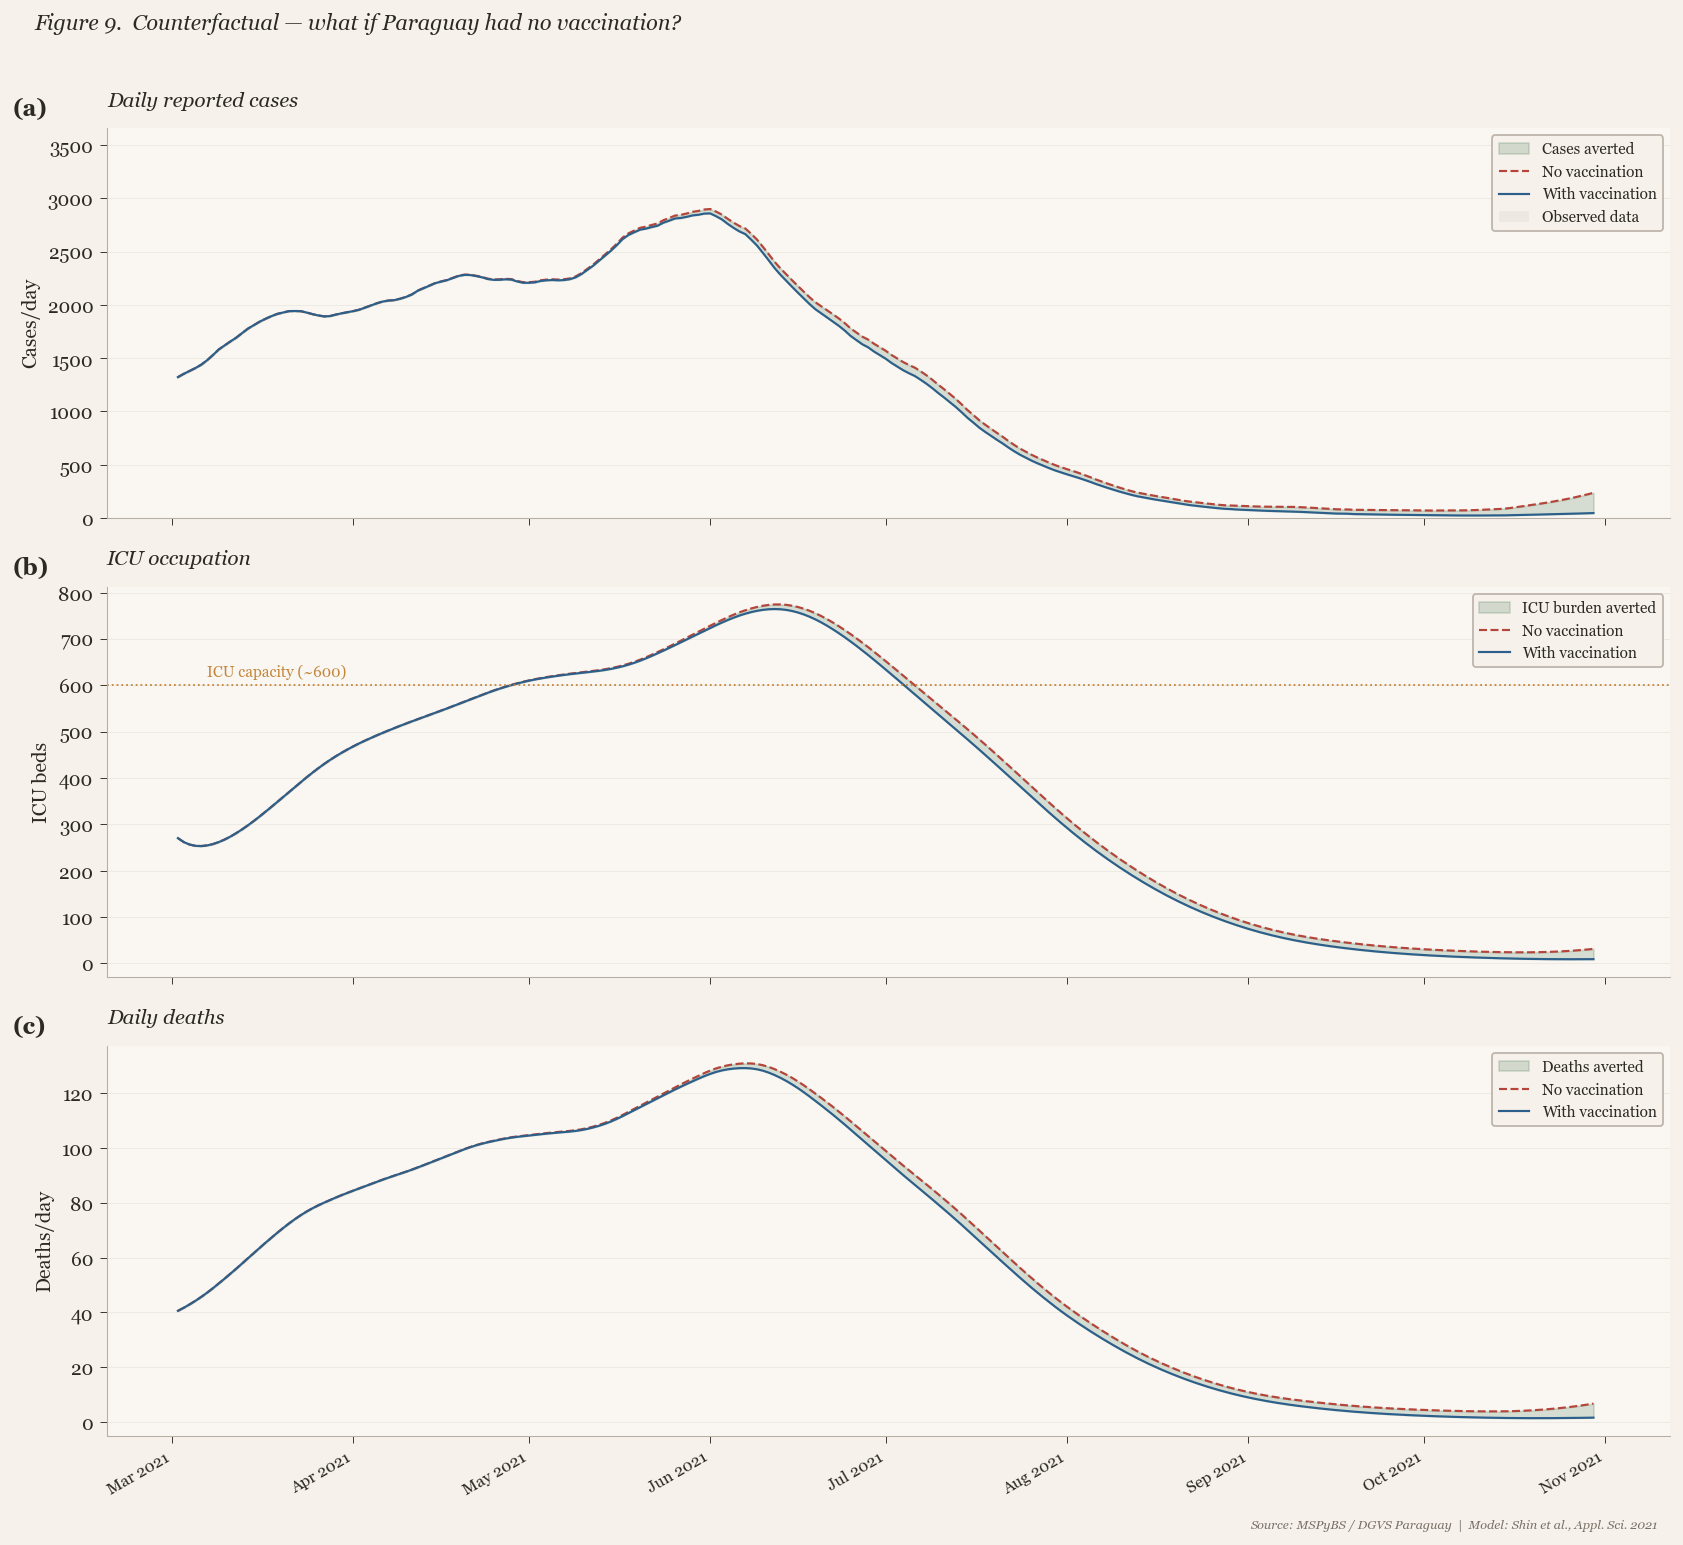

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
fig.subplots_adjust(hspace=0.15)
n_plot = min(len(dR_vax), len(dR_novx), len(cf_dates)-1)
cd = cf_dates[:n_plot]

# (a) Daily cases
ax = axes[0]
ax.fill_between(cd, dR_vax[:n_plot], dR_novx[:n_plot],
                color=GREEN, alpha=0.2, label='Cases averted')
ax.plot(cd, dR_novx[:n_plot], color=RED, lw=1.2, ls='--', label='No vaccination')
ax.plot(cd, dR_vax[:n_plot], color=BLUE, lw=1.2, label='With vaccination')
ax.bar(cf_dates[:n_plot+1], DR_ext[j_vax:j_vax+n_plot+1],
       width=1, alpha=0.15, color=BAR_DATA, linewidth=0, label='Observed data')
style_ax(ax, title='Daily reported cases', ylabel='Cases/day')
ax.legend(loc='upper right', fontsize=8.5); panel_label(ax, '(a)')

# (b) ICU
ax = axes[1]
ax.fill_between(cd, U_vax[:n_plot], U_novx[:n_plot],
                color=GREEN, alpha=0.2, label='ICU burden averted')
ax.plot(cd, U_novx[:n_plot], color=RED, lw=1.2, ls='--', label='No vaccination')
ax.plot(cd, U_vax[:n_plot], color=BLUE, lw=1.2, label='With vaccination')
ax.axhline(600, color=AMBER, ls=':', lw=1)
ax.text(cd[5], 620, 'ICU capacity (~600)', color=AMBER, fontsize=8.5)
style_ax(ax, title='ICU occupation', ylabel='ICU beds')
ax.legend(loc='upper right', fontsize=8.5); panel_label(ax, '(b)')

# (c) Daily deaths
ax = axes[2]
ax.fill_between(cd, dF_vax[:n_plot], dF_novx[:n_plot],
                color=GREEN, alpha=0.2, label='Deaths averted')
ax.plot(cd, dF_novx[:n_plot], color=RED, lw=1.2, ls='--', label='No vaccination')
ax.plot(cd, dF_vax[:n_plot], color=BLUE, lw=1.2, label='With vaccination')
style_ax(ax, title='Daily deaths', ylabel='Deaths/day')
ax.legend(loc='upper right', fontsize=8.5); panel_label(ax, '(c)')

fig.suptitle('Figure 9.  Counterfactual — what if Paraguay had no vaccination?',
             fontsize=12, x=0.02, ha='left', fontstyle='italic')
date_fmt(axes[-1], interval=1)
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.97]); plt.show()

## 18. Immunity Landscape

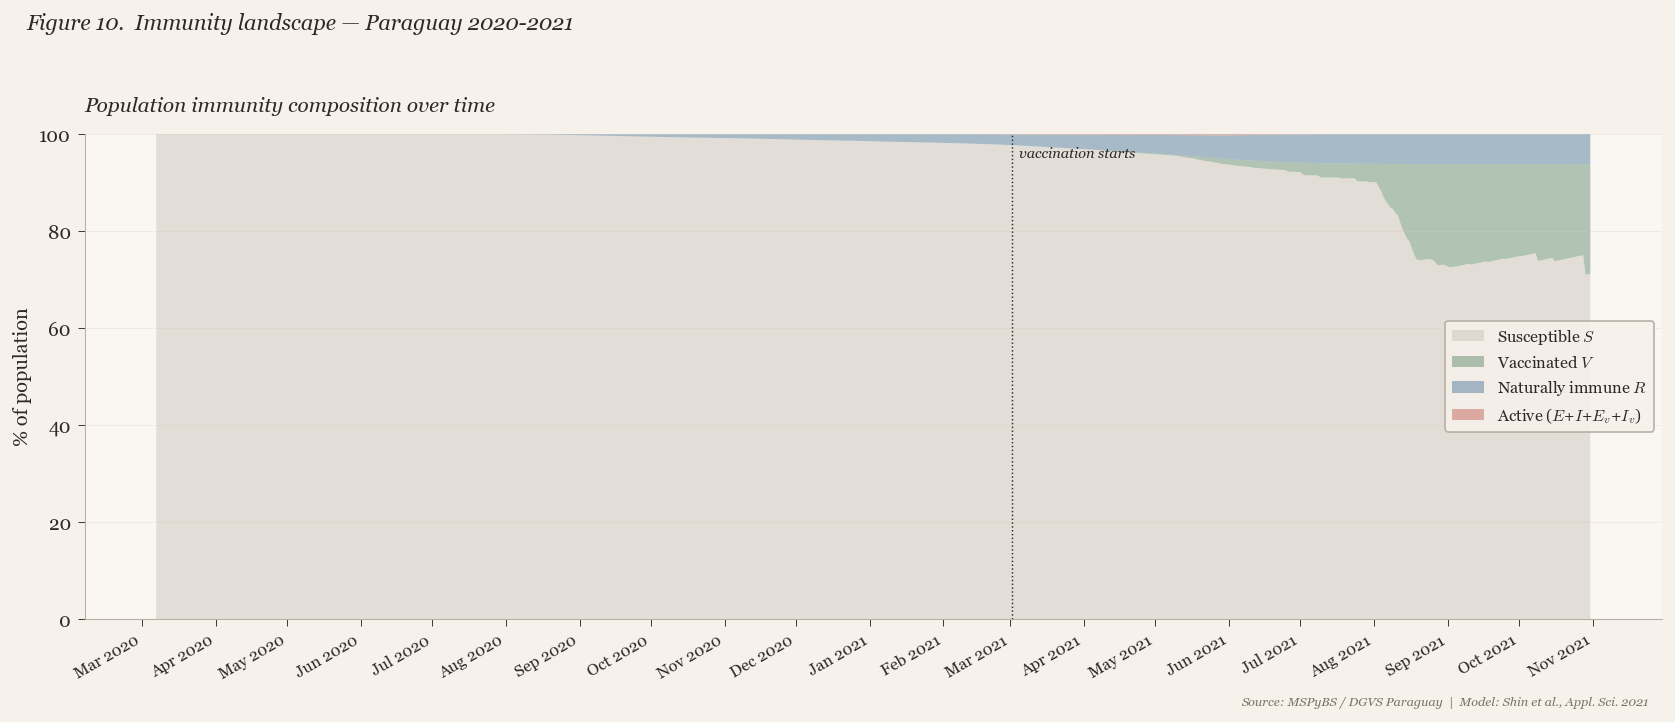

In [27]:
# S, V, E, I, Ev, Iv, R
St  = states_ext[:n_days_ext, 0]
Vt  = states_ext[:n_days_ext, 1]
Et  = states_ext[:n_days_ext, 2]
It  = states_ext[:n_days_ext, 3]
Evt = states_ext[:n_days_ext, 4]
Ivt = states_ext[:n_days_ext, 5]
Rt  = states_ext[:n_days_ext, 6]
Active_t = Et + It + Evt + Ivt

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(dates_ext[:n_days_ext],
             St/N_pop*100, Vt/N_pop*100, Rt/N_pop*100, Active_t/N_pop*100,
             labels=['Susceptible $S$', 'Vaccinated $V$',
                     'Naturally immune $R$', 'Active ($E$+$I$+$E_v$+$I_v$)'],
             colors=[BAR_DATA, GREEN, BLUE, RED],
             alpha=[0.4, 0.5, 0.5, 0.7])
ax.axvline(vax_start, color=TEXT, ls=':', lw=0.8)
ax.text(vax_start, 95, '  vaccination starts', fontsize=8, color=TEXT, fontstyle='italic')
ax.set_ylim(0, 100)
style_ax(ax, title='Population immunity composition over time',
         ylabel='% of population')
ax.legend(loc='center right', fontsize=9); date_fmt(ax, interval=1)
fig.suptitle('Figure 10.  Immunity landscape — Paraguay 2020-2021',
             fontsize=12, x=0.02, ha='left', fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.015,1,0.95]); plt.show()

## 19. Summary of Vaccination Extension

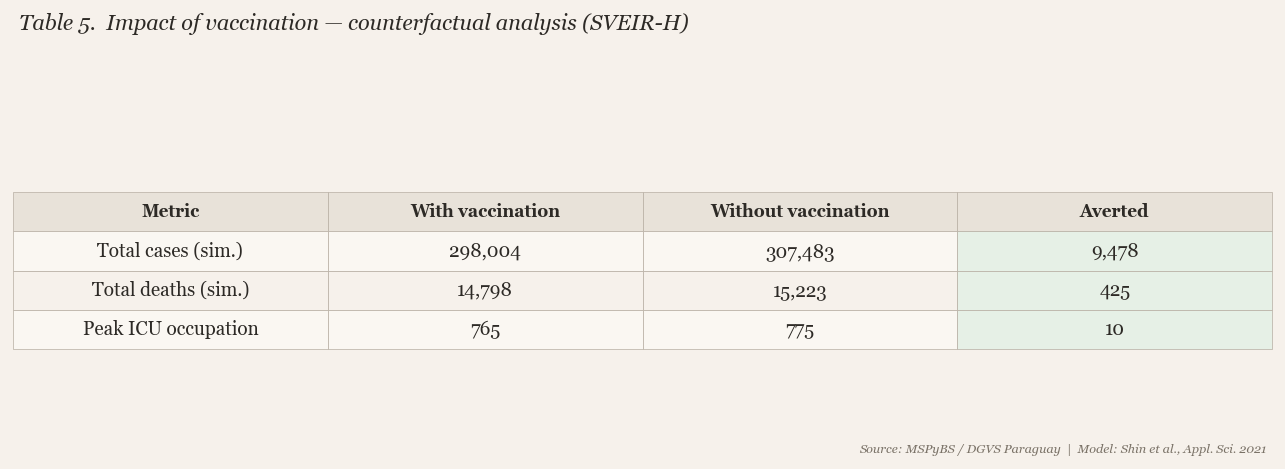

In [28]:
total_cases_averted  = dR_novx.sum() - dR_vax.sum()
total_deaths_averted = dF_novx.sum() - dF_vax.sum()
peak_icu_novax = max(U_novx)
peak_icu_vax   = max(U_vax)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')
col_labels = ['Metric', 'With vaccination', 'Without vaccination', 'Averted']
cell_text = [
    ['Total cases (sim.)', f'{dR_vax.sum():,.0f}', f'{dR_novx.sum():,.0f}',
     f'{total_cases_averted:,.0f}'],
    ['Total deaths (sim.)', f'{dF_vax.sum():,.0f}', f'{dF_novx.sum():,.0f}',
     f'{total_deaths_averted:,.0f}'],
    ['Peak ICU occupation', f'{peak_icu_vax:,.0f}', f'{peak_icu_novax:,.0f}',
     f'{peak_icu_novax-peak_icu_vax:,.0f}'],
]
table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10.5); table.scale(1.0, 2.0)
for (row,col), cell in table.get_celld().items():
    cell.set_edgecolor(RULE); cell.set_linewidth(0.4)
    cell.set_text_props(color=TEXT, fontfamily='serif')
    if row == 0:
        cell.set_facecolor('#e8e2d9')
        cell.set_text_props(fontweight='bold', color=TEXT, fontsize=9.5)
    elif col == 3:
        cell.set_facecolor('#e6f0e6')
    else:
        cell.set_facecolor(PANEL if row%2==1 else BG)
fig.suptitle('Table 5.  Impact of vaccination — counterfactual analysis (SVEIR-H)',
             fontsize=12, x=0.02, ha='left', fontstyle='italic')
source_note(fig); plt.tight_layout(rect=[0,0.02,1,0.90]); plt.show()

---
## Summary

| Component | Paper | This notebook |
|-----------|-------|---------------|
| $\\beta(t)$ estimation | Stan MCMC, 30 chains x 3000 iter | scipy L-BFGS-B (MAP) |
| $\\lambda_*$ estimation | Stan MCMC, 60 chains x 3000 iter | scipy L-BFGS-B (MAP) |
| ODE solver | RK4/5 inside Stan | Forward Euler (dt=1 day) |
| Hospital $\\lambda_*$ freq. | Daily | Every 7 days |
| **Total runtime** | **Hours** | **~2-5 minutes** |